In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ahsanneural/pakistan-air-quality-and-weather-10-cities/pakistan_air_quality_final_clean_v2.csv
/kaggle/input/datasets/ahsanneural/pakistan-air-quality-and-weather-10-cities/DATA_QUALITY_REPORT.md


# Step 1

## 1️⃣ Load DataSet

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Dataset path
DATA_PATH = "/kaggle/input/datasets/ahsanneural/pakistan-air-quality-and-weather-10-cities/pakistan_air_quality_final_clean_v2.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")

✅ Dataset loaded successfully!
Shape: (21840, 26)


## 2️⃣ Basic Dataset Information

In [4]:
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]}")

print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

DATASET INFORMATION
Rows       : 21,840
Columns    : 26

Column Names:
1. timestamp
2. city
3. latitude
4. longitude
5. pm10
6. pm2_5
7. carbon_monoxide
8. nitrogen_dioxide
9. sulphur_dioxide
10. ozone
11. dust
12. temperature
13. humidity
14. precipitation
15. wind_speed
16. wind_direction
17. pressure
18. date
19. hour
20. day_of_week
21. month
22. month_name
23. year
24. is_weekend
25. season
26. aqi_category


## 3️⃣ First & Last Records

In [5]:
print("First 5 Records:")
display(df.head())

print("\nLast 5 Records:")
display(df.tail())

First 5 Records:


,timestamp,city,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,pressure,date,hour,day_of_week,month,month_name,year,is_weekend,season,aqi_category
0,2025-11-06 00:00:00,Faisalabad,31.4504,73.135,23.7,22.6,598.0,15.9,5.0,58.0,...,1013.3,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Moderate
1,2025-11-06 01:00:00,Faisalabad,31.4504,73.135,25.4,24.2,790.0,21.7,5.6,51.0,...,1013.2,2025-11-06,1,Thursday,11,November,2025,0,Autumn,Moderate
2,2025-11-06 02:00:00,Faisalabad,31.4504,73.135,32.2,30.7,1048.0,29.4,6.5,42.0,...,1013.0,2025-11-06,2,Thursday,11,November,2025,0,Autumn,Moderate
3,2025-11-06 03:00:00,Faisalabad,31.4504,73.135,36.2,34.8,1176.0,33.2,7.2,42.0,...,1012.7,2025-11-06,3,Thursday,11,November,2025,0,Autumn,Moderate
4,2025-11-06 04:00:00,Faisalabad,31.4504,73.135,34.7,33.3,1053.0,29.3,7.6,58.0,...,1012.5,2025-11-06,4,Thursday,11,November,2025,0,Autumn,Moderate



Last 5 Records:


,timestamp,city,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,pressure,date,hour,day_of_week,month,month_name,year,is_weekend,season,aqi_category
21835,2026-02-04 19:00:00,Sialkot,32.4945,74.5229,50.6,48.8,640.0,14.1,10.3,57.0,...,1020.9,2026-02-04,19,Wednesday,2,February,2026,0,Winter,Unhealthy for Sensitive Groups
21836,2026-02-04 20:00:00,Sialkot,32.4945,74.5229,47.5,45.9,659.0,12.8,9.4,55.0,...,1021.0,2026-02-04,20,Wednesday,2,February,2026,0,Winter,Unhealthy for Sensitive Groups
21837,2026-02-04 21:00:00,Sialkot,32.4945,74.5229,45.6,44.0,689.0,12.0,8.6,53.0,...,1021.2,2026-02-04,21,Wednesday,2,February,2026,0,Winter,Unhealthy for Sensitive Groups
21838,2026-02-04 22:00:00,Sialkot,32.4945,74.5229,45.1,43.3,740.0,11.5,7.9,51.0,...,1021.3,2026-02-04,22,Wednesday,2,February,2026,0,Winter,Unhealthy for Sensitive Groups
21839,2026-02-04 23:00:00,Sialkot,32.4945,74.5229,45.8,43.8,802.0,11.5,7.5,48.0,...,1020.9,2026-02-04,23,Wednesday,2,February,2026,0,Winter,Unhealthy for Sensitive Groups


## 4️⃣ Data Types & Structure

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         21840 non-null  object 
 1   city              21840 non-null  object 
 2   latitude          21840 non-null  float64
 3   longitude         21840 non-null  float64
 4   pm10              21840 non-null  float64
 5   pm2_5             21840 non-null  float64
 6   carbon_monoxide   21840 non-null  float64
 7   nitrogen_dioxide  21840 non-null  float64
 8   sulphur_dioxide   21840 non-null  float64
 9   ozone             21840 non-null  float64
 10  dust              21840 non-null  float64
 11  temperature       21840 non-null  float64
 12  humidity          21840 non-null  float64
 13  precipitation     21840 non-null  float64
 14  wind_speed        21840 non-null  float64
 15  wind_direction    21840 non-null  float64
 16  pressure          21840 non-null  float6

## 5️⃣ Missing Values

In [7]:
print(df.isnull().sum())

timestamp           0
city                0
latitude            0
longitude           0
pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
dust                0
temperature         0
humidity            0
precipitation       0
wind_speed          0
wind_direction      0
pressure            0
date                0
hour                0
day_of_week         0
month               0
month_name          0
year                0
is_weekend          0
season              0
aqi_category        0
dtype: int64


## 6️⃣ Duplicates

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 7️⃣ Statistics

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
latitude,21840.0,31.037740,2.670825,24.8607,30.1575,31.50005,33.5651,34.0151
longitude,21840.0,71.538740,2.583617,66.9750,70.2952,72.27090,73.1350,74.5229
pm10,21840.0,88.416575,66.010440,0.5000,40.5000,68.50000,117.8000,488.0000
pm2_5,21840.0,82.968141,65.742106,0.5000,34.7000,62.40000,112.5000,486.2000
carbon_monoxide,21840.0,1580.858700,1145.632800,91.0000,741.0000,1296.50000,2113.2500,11482.0000
nitrogen_dioxide,21840.0,39.470870,32.286339,0.0000,13.4000,30.40000,57.8000,185.1000
sulphur_dioxide,21840.0,19.466383,11.582885,0.1000,10.6000,17.70000,26.3000,75.1000
ozone,21840.0,63.802106,50.401229,0.0000,21.0000,55.00000,100.0000,265.0000
dust,21840.0,9.858242,32.531054,0.0000,1.0000,3.00000,8.0000,711.0000
temperature,21840.0,13.929638,5.688352,-5.9000,9.8000,13.30000,17.8000,31.7000


## 8️⃣ Cities

In [10]:
print("Number of cities:", df["city"].nunique())
print("\nCities:")
print(df["city"].unique())

print("\nRecords per city:")
print(df["city"].value_counts())

Number of cities: 10

Cities:
['Faisalabad' 'Islamabad' 'Karachi' 'Lahore' 'Multan' 'Peshawar' 'Quetta'
 'Rahim Yar Khan' 'Rawalpindi' 'Sialkot']

Records per city:
city
Faisalabad        2184
Islamabad         2184
Karachi           2184
Lahore            2184
Multan            2184
Peshawar          2184
Quetta            2184
Rahim Yar Khan    2184
Rawalpindi        2184
Sialkot           2184
Name: count, dtype: int64


# STEP 2 — Exploratory Data Analysis (EDA)

## 2.1 Convert Date and Time Columns

In [11]:
# Convert timestamp and date columns to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Display data types
print("Timestamp dtype:", df["timestamp"].dtype)
print("Date dtype:", df["date"].dtype)

# Display date range
print("\nDataset Start:", df["timestamp"].min())
print("Dataset End  :", df["timestamp"].max())

Timestamp dtype: datetime64[ns]
Date dtype: datetime64[ns]

Dataset Start: 2025-11-06 00:00:00
Dataset End  : 2026-02-04 23:00:00


## 2.2 Analyze Dataset Time Coverage

In [12]:
# Calculate time coverage
start_date = df["timestamp"].min()
end_date = df["timestamp"].max()

total_days = df["timestamp"].dt.date.nunique()
total_timestamps = df["timestamp"].nunique()

print("=" * 60)
print("DATASET TIME COVERAGE")
print("=" * 60)

print(f"Start Date       : {start_date}")
print(f"End Date         : {end_date}")
print(f"Total Days       : {total_days}")
print(f"Unique Timestamps: {total_timestamps}")

DATASET TIME COVERAGE
Start Date       : 2025-11-06 00:00:00
End Date         : 2026-02-04 23:00:00
Total Days       : 91
Unique Timestamps: 2184


## 2.3 City-wise PM2.5 Distribution

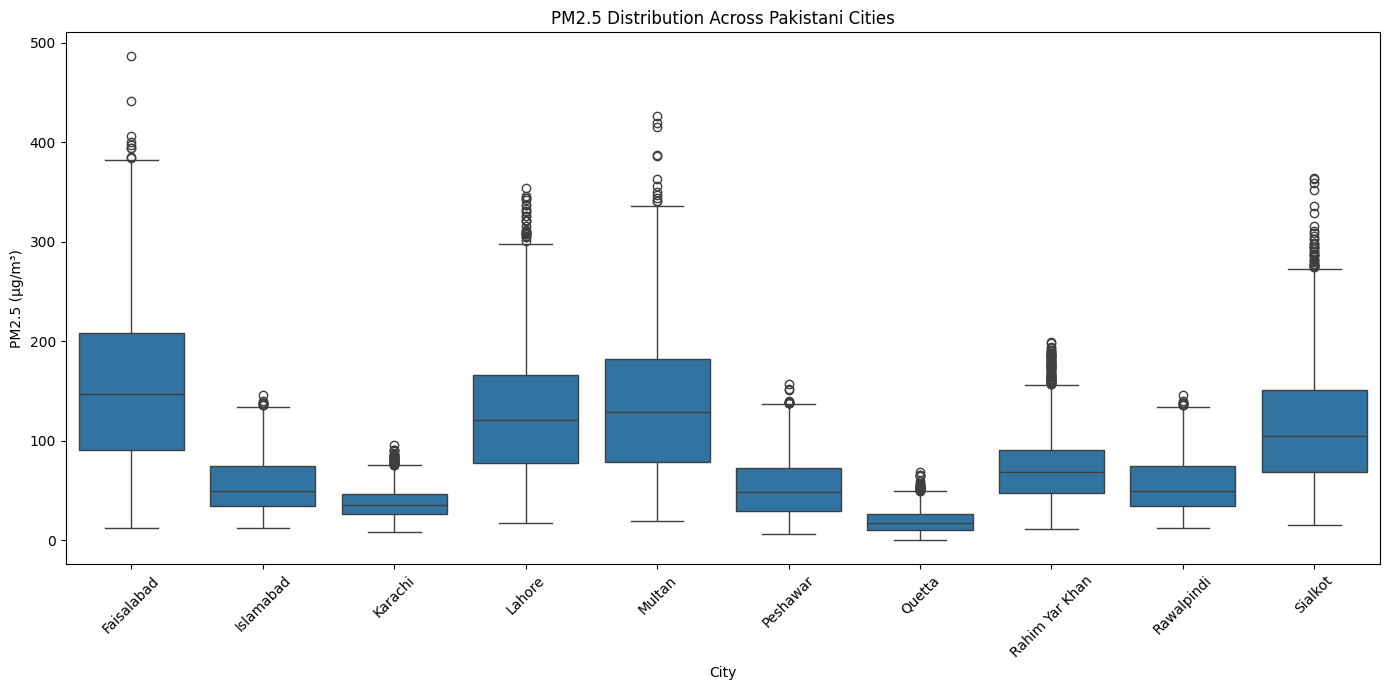

In [13]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="city",
    y="pm2_5"
)

plt.title("PM2.5 Distribution Across Pakistani Cities")
plt.xlabel("City")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 2.4 Average PM2.5 by City

In [14]:
city_pm25 = (
    df.groupby("city")["pm2_5"]
    .mean()
    .sort_values(ascending=False)
)

print("Average PM2.5 by City:")
display(city_pm25.to_frame("Average PM2.5"))

Average PM2.5 by City:


,Average PM2.5
city,
Faisalabad,155.736310
Multan,136.831777
Lahore,126.761264
Sialkot,115.192582
Rahim Yar Khan,72.364927
Islamabad,56.125504
Rawalpindi,56.125504
Peshawar,53.729579
Karachi,37.708974


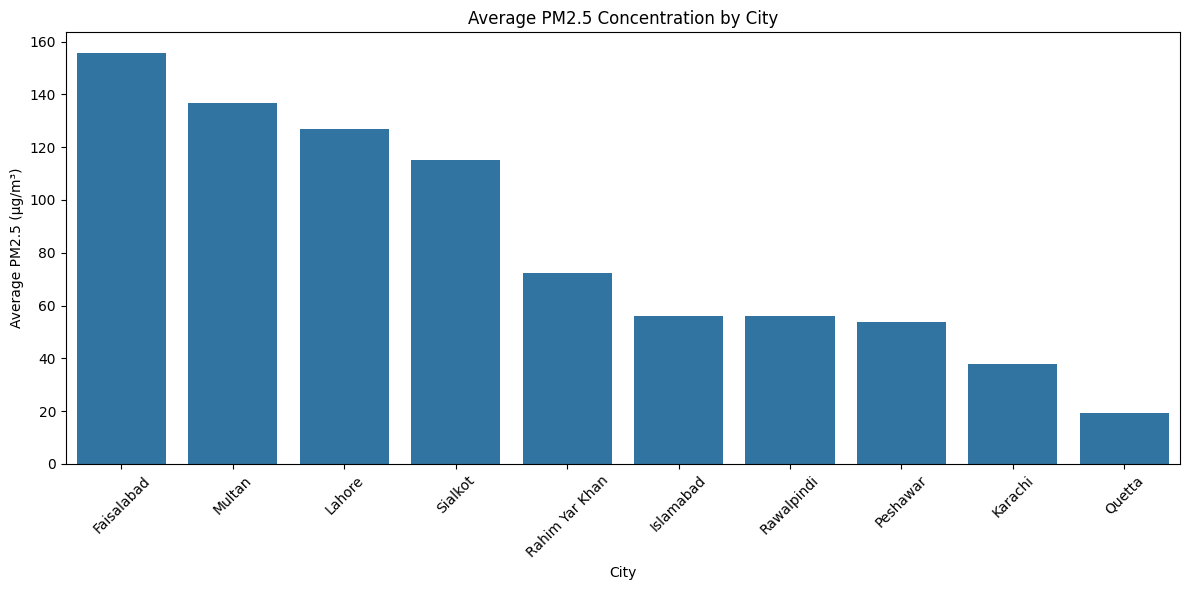

In [15]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=city_pm25.index,
    y=city_pm25.values
)

plt.title("Average PM2.5 Concentration by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 2.5 PM10 vs PM2.5 Relationship

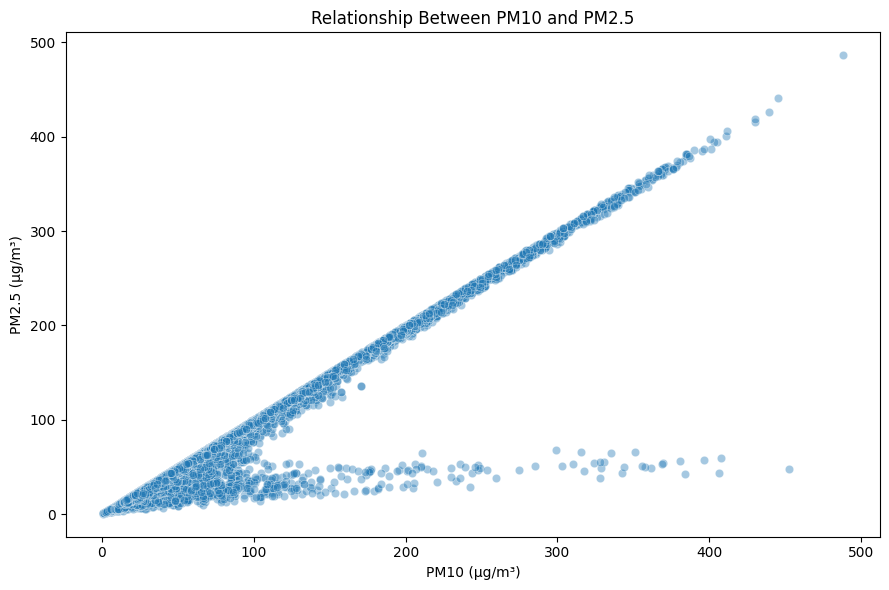

In [16]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="pm10",
    y="pm2_5",
    alpha=0.4
)

plt.title("Relationship Between PM10 and PM2.5")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

## 2.6 PM2.5 Distribution Analysis

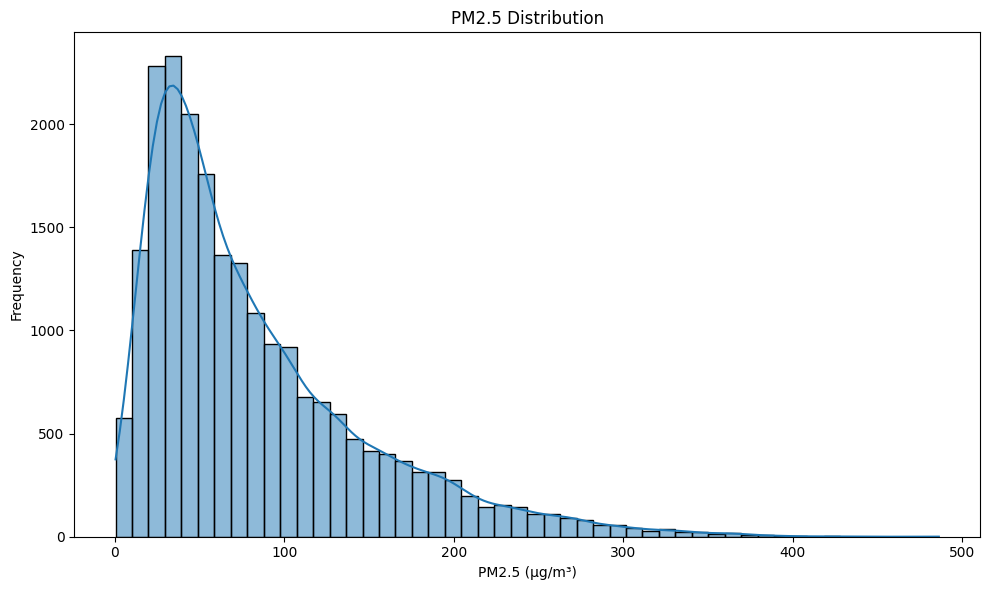

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="pm2_5",
    bins=50,
    kde=True
)

plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [18]:
print("PM2.5 Statistics:")
display(df["pm2_5"].describe())

PM2.5 Statistics:


count    21840.000000
mean        82.968141
std         65.742106
min          0.500000
25%         34.700000
50%         62.400000
75%        112.500000
max        486.200000
Name: pm2_5, dtype: float64

## 2.7 PM10 Distribution Analysis

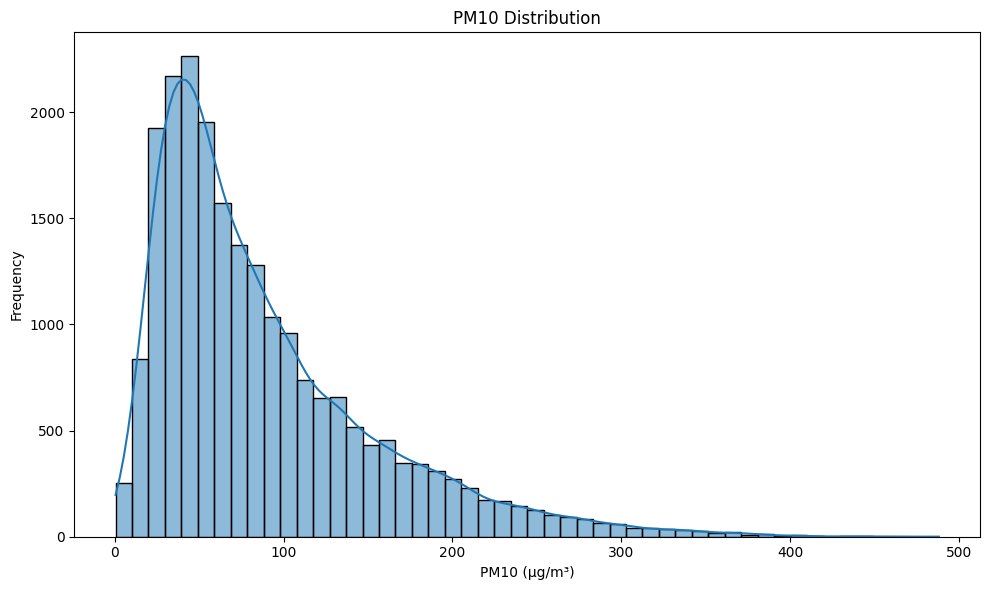

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="pm10",
    bins=50,
    kde=True
)

plt.title("PM10 Distribution")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2.8 Hourly PM2.5 Pattern

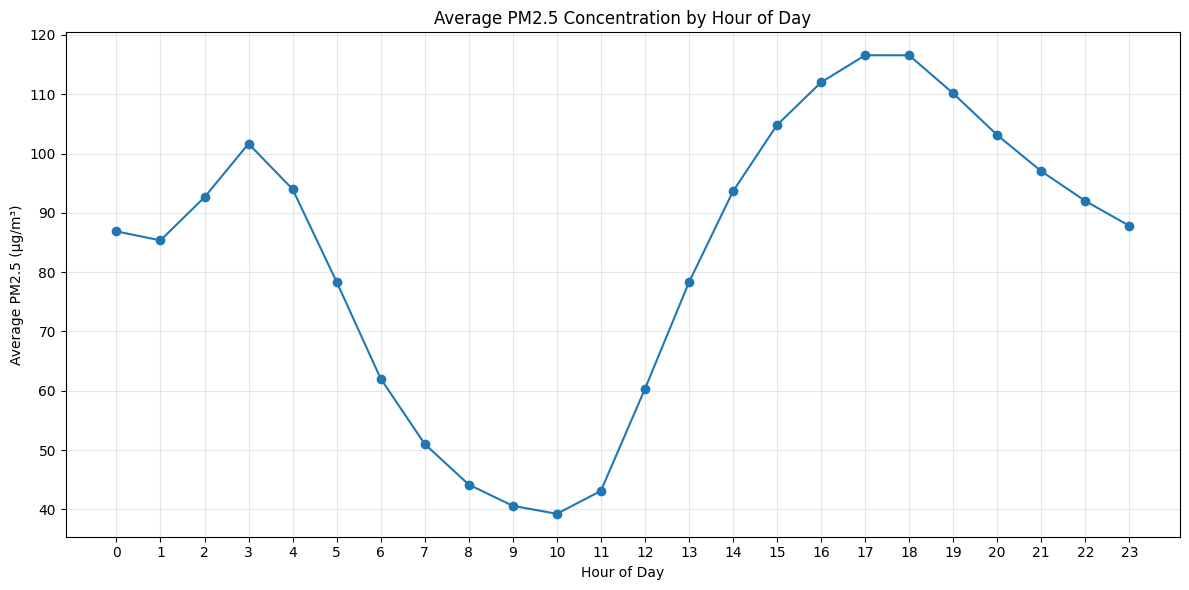

In [20]:
hourly_pm25 = (
    df.groupby("hour")["pm2_5"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_pm25.index,
    hourly_pm25.values,
    marker="o"
)

plt.title("Average PM2.5 Concentration by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(range(24))

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.9 Day-of-Week PM2.5 Analysis

In [21]:
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_pm25 = (
    df.groupby("day_of_week")["pm2_5"]
    .mean()
    .reindex(days_order)
)

display(day_pm25.to_frame("Average PM2.5"))

,Average PM2.5
day_of_week,
Monday,84.354712
Tuesday,81.892372
Wednesday,81.599840
Thursday,80.845032
Friday,83.570737
Saturday,82.492853
Sunday,86.021442


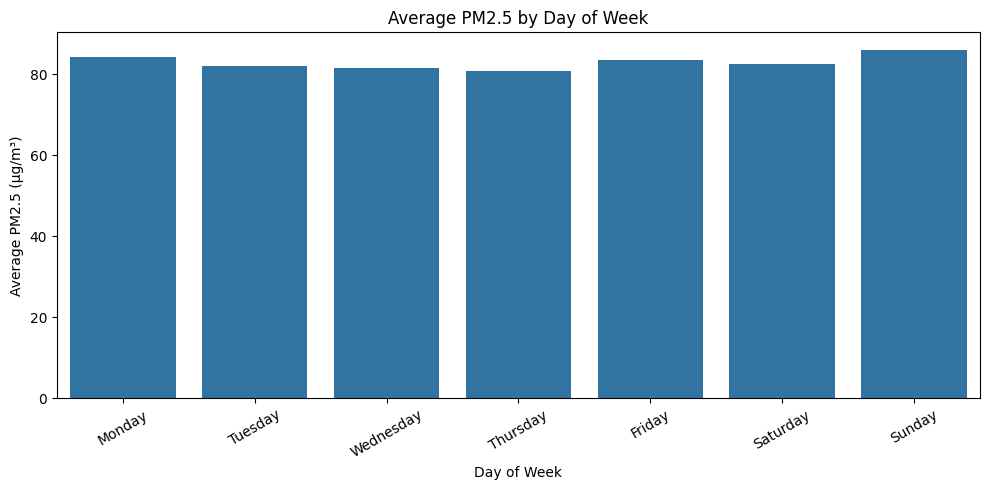

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_pm25.index,
    y=day_pm25.values
)

plt.title("Average PM2.5 by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 2.10 Seasonal PM2.5 Analysis

In [23]:
season_pm25 = (
    df.groupby("season")["pm2_5"]
    .mean()
    .sort_values(ascending=False)
)

display(
    season_pm25.to_frame("Average PM2.5")
)

,Average PM2.5
season,
Winter,87.555000
Autumn,70.858833


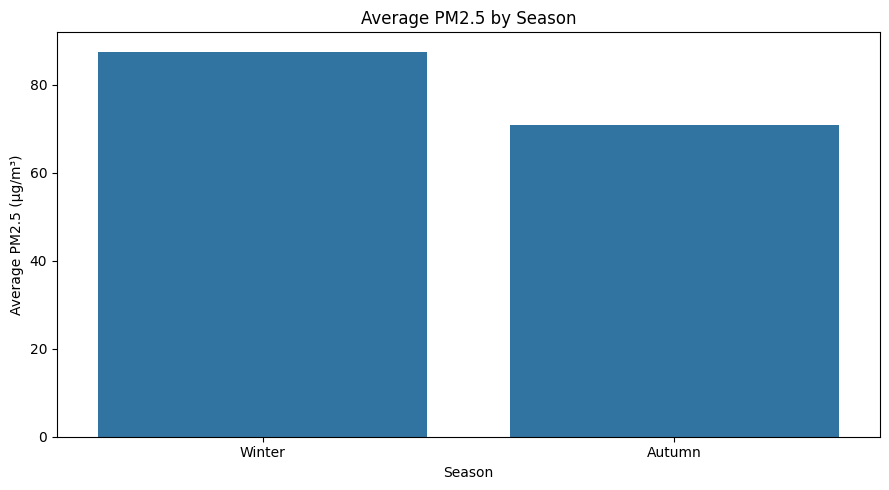

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_pm25.index,
    y=season_pm25.values
)

plt.title("Average PM2.5 by Season")
plt.xlabel("Season")
plt.ylabel("Average PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

## 2.11 Temperature vs PM2.5

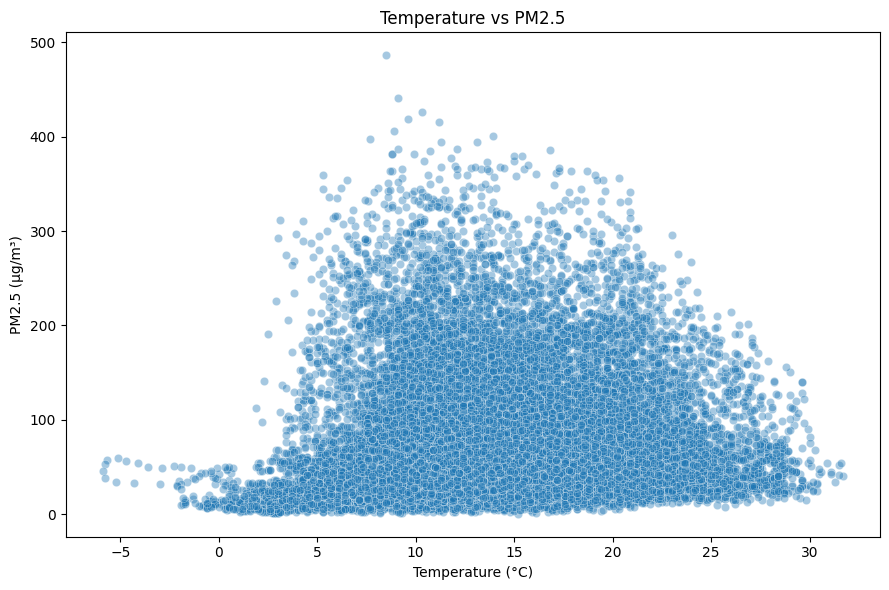

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="temperature",
    y="pm2_5",
    alpha=0.4
)

plt.title("Temperature vs PM2.5")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

## 2.12 Humidity vs PM2.5

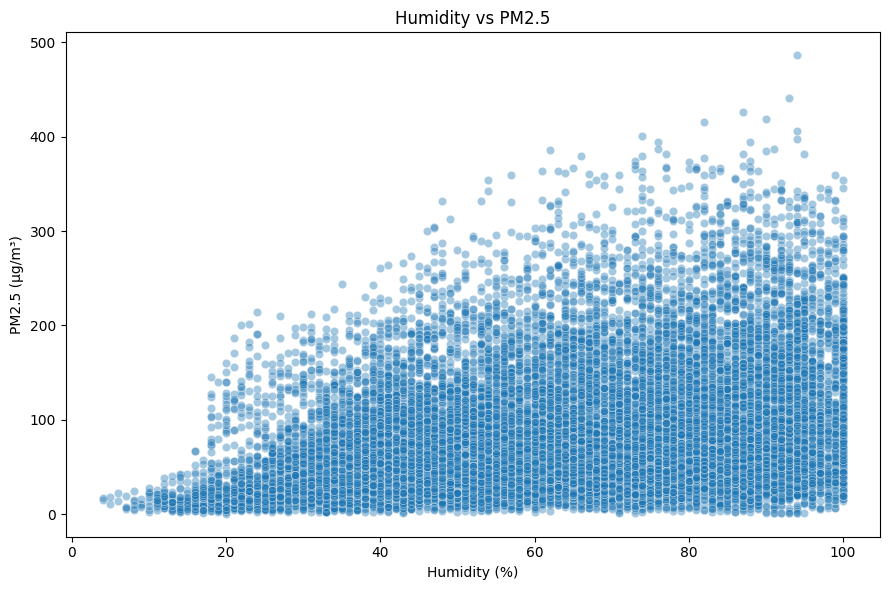

In [26]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="humidity",
    y="pm2_5",
    alpha=0.4
)

plt.title("Humidity vs PM2.5")
plt.xlabel("Humidity (%)")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

## 2.13 Wind Speed vs PM2.5

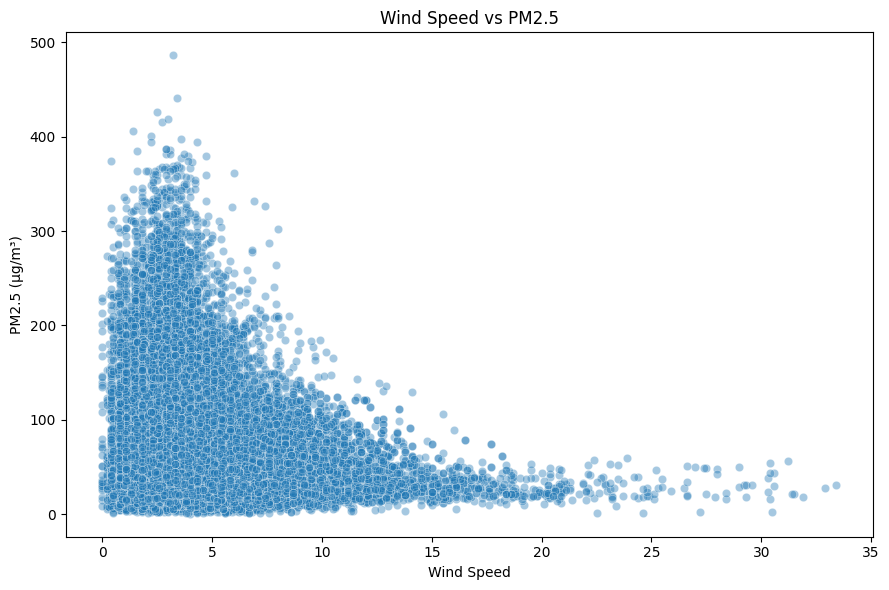

In [27]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="wind_speed",
    y="pm2_5",
    alpha=0.4
)

plt.title("Wind Speed vs PM2.5")
plt.xlabel("Wind Speed")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

## 2.14 Correlation Analysis

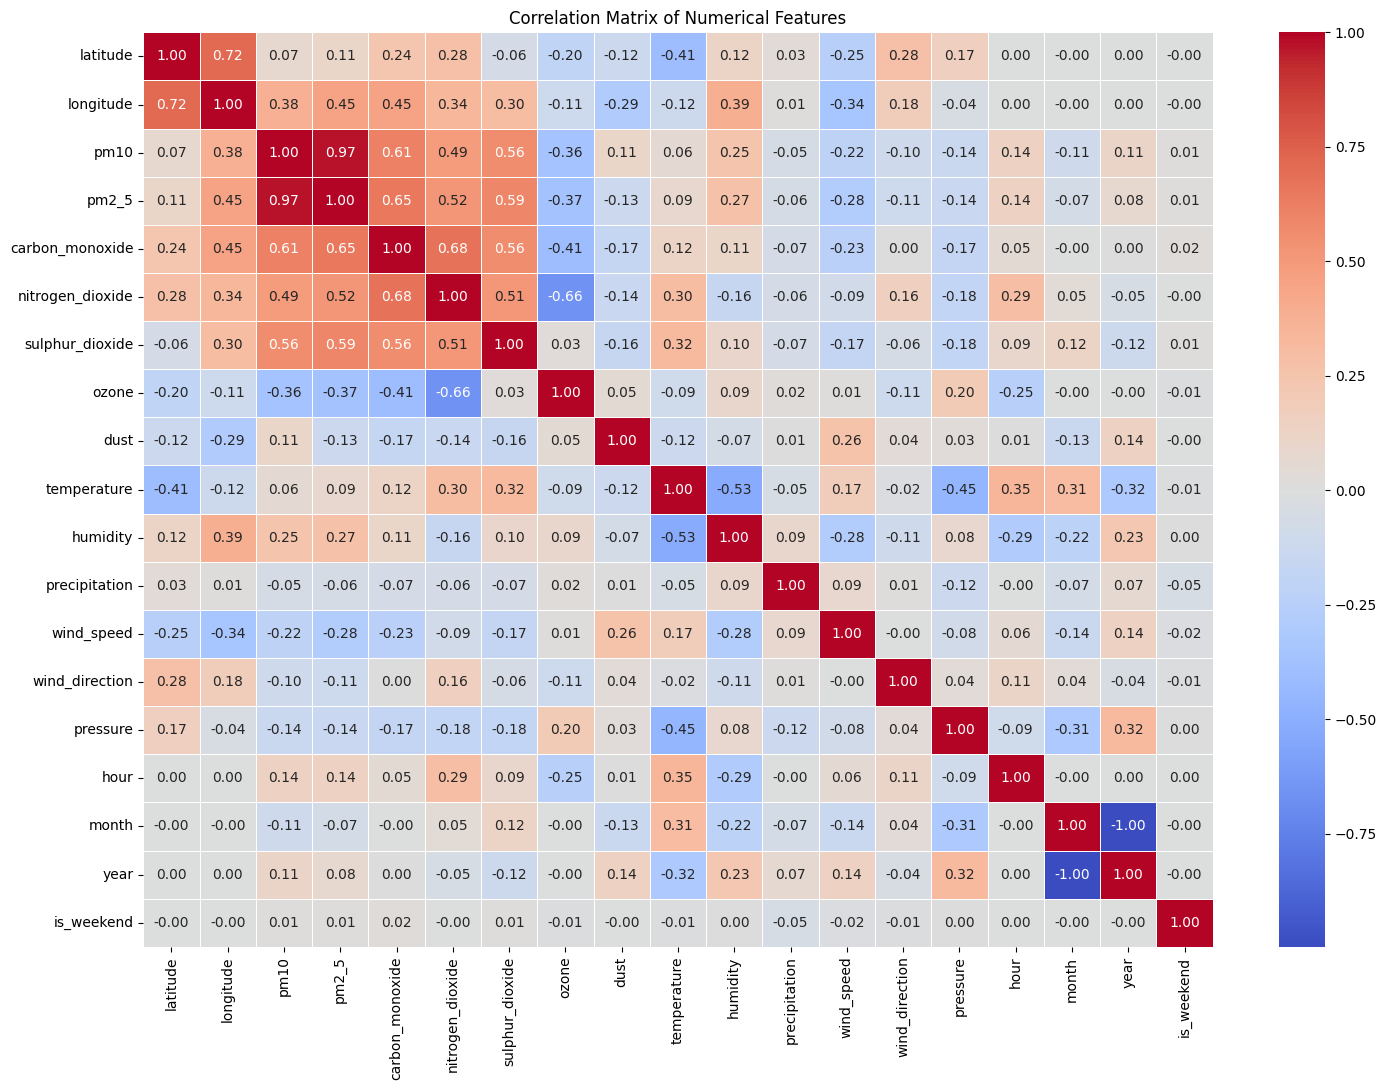

In [28]:
# Select numerical columns
numeric_df = df.select_dtypes(
    include=np.number
)

# Calculate correlation
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

## 2.15 PM2.5 Correlation Ranking

In [29]:
pm25_correlation = (
    correlation_matrix["pm2_5"]
    .sort_values(ascending=False)
)

print("Correlation with PM2.5:")
display(
    pm25_correlation.to_frame("Correlation")
)

Correlation with PM2.5:


,Correlation
pm2_5,1.000000
pm10,0.971485
carbon_monoxide,0.652475
sulphur_dioxide,0.593744
nitrogen_dioxide,0.516805
longitude,0.450197
humidity,0.268562
hour,0.136466
latitude,0.107163
temperature,0.086806


## 2.16 AQI Category Distribution

In [30]:
aqi_counts = (
    df["aqi_category"]
    .value_counts()
)

print("AQI Category Distribution:")
display(
    aqi_counts.to_frame("Count")
)

AQI Category Distribution:


,Count
aqi_category,
Unhealthy,8766
Moderate,4861
Unhealthy for Sensitive Groups,4199
Very Unhealthy,2617
Good,759
Hazardous,638


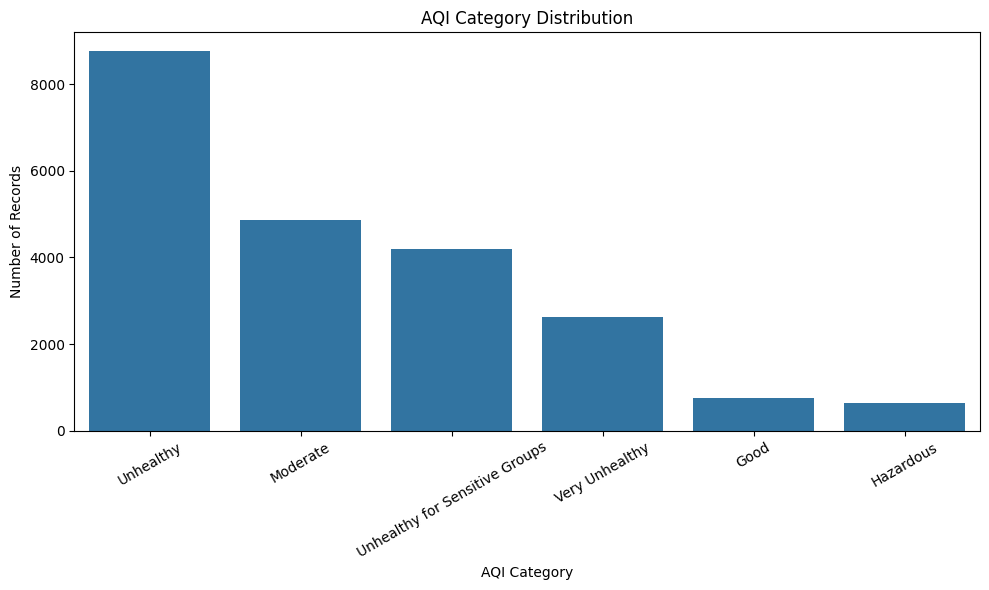

In [31]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="aqi_category",
    order=df["aqi_category"].value_counts().index
)

plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 2.17 City-wise AQI Category Analysis

In [32]:
city_aqi = pd.crosstab(
    df["city"],
    df["aqi_category"],
    normalize="index"
) * 100

display(city_aqi.round(2))

aqi_category,Good,Hazardous,Moderate,Unhealthy,Unhealthy for Sensitive Groups,Very Unhealthy
city,,,,,,
Faisalabad,0.00,14.29,4.12,41.39,6.46,33.75
Islamabad,0.09,0.00,26.92,41.71,31.27,0.00
Karachi,0.41,0.00,48.26,12.77,38.55,0.00
Lahore,0.00,4.12,3.75,53.75,9.43,28.94
Multan,0.00,8.01,4.30,48.67,8.01,31.00
Peshawar,2.11,0.00,31.36,40.98,25.41,0.14
Quetta,31.82,0.00,60.62,0.46,7.10,0.00
Rahim Yar Khan,0.23,0.00,12.64,60.90,22.57,3.66
Rawalpindi,0.09,0.00,26.92,41.71,31.27,0.00


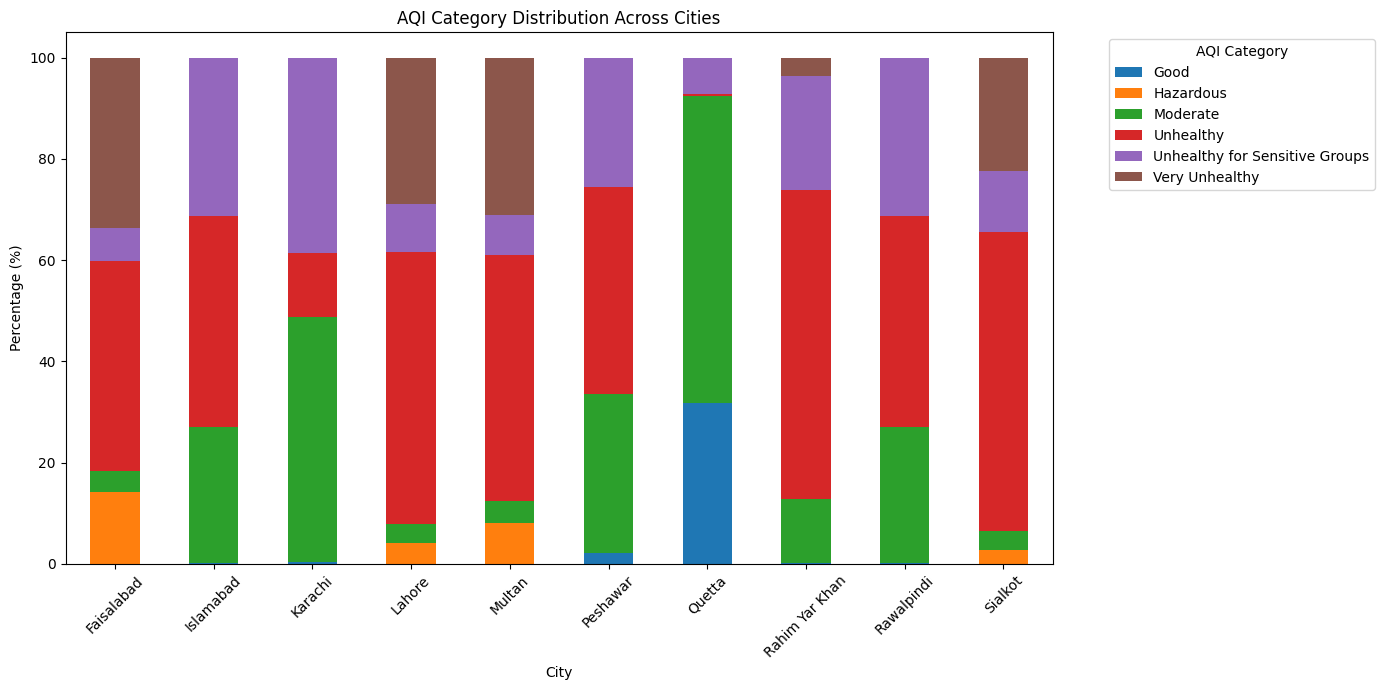

In [33]:
city_aqi.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("AQI Category Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(
    title="AQI Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 2.18 PM2.5 by City and Hour

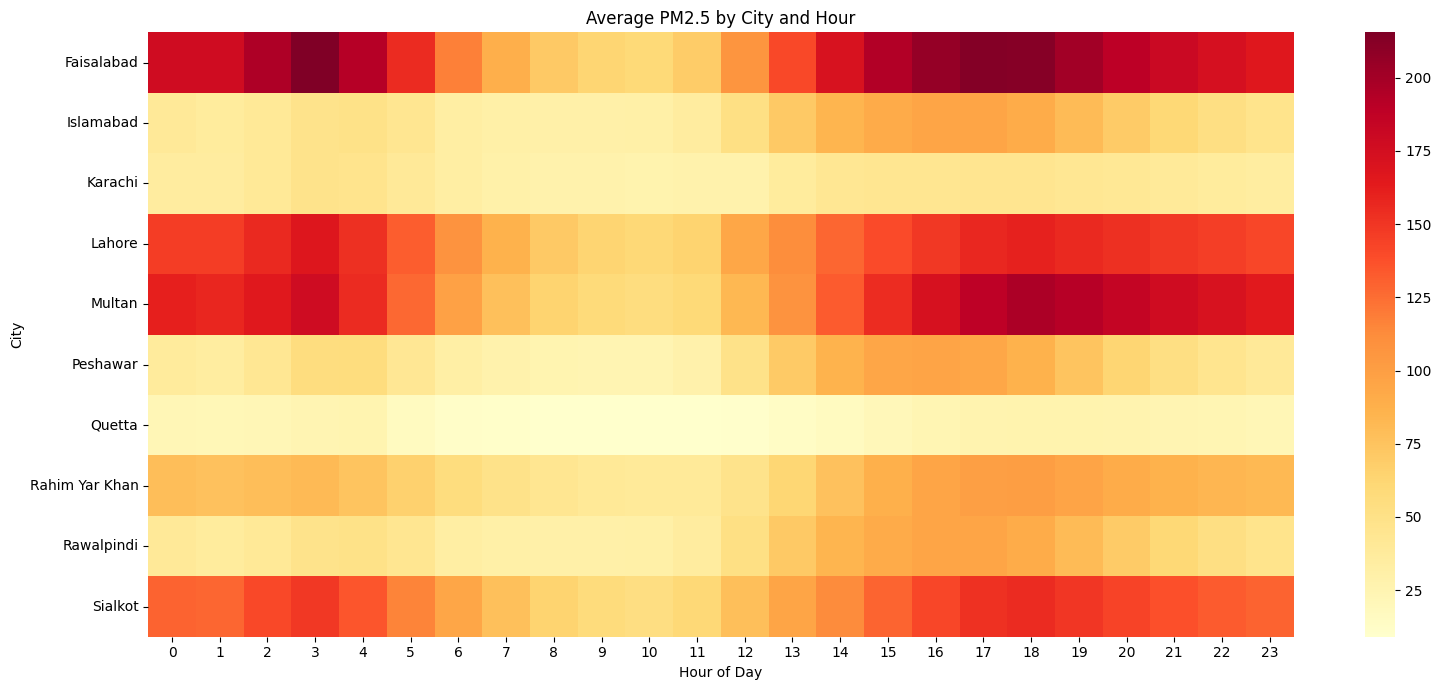

In [34]:
city_hour_pm25 = df.pivot_table(
    values="pm2_5",
    index="city",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    city_hour_pm25,
    cmap="YlOrRd",
    annot=False
)

plt.title("Average PM2.5 by City and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("City")

plt.tight_layout()
plt.show()

# COMPLETE EXPLORATORY DATA ANALYSIS REPORT

CREATING COMPLETE EDA VISUALIZATION DASHBOARD
Plots directory: plots/
EDA dataset shape: (21840, 26)
Target column selected: pm2_5
Datetime column: date


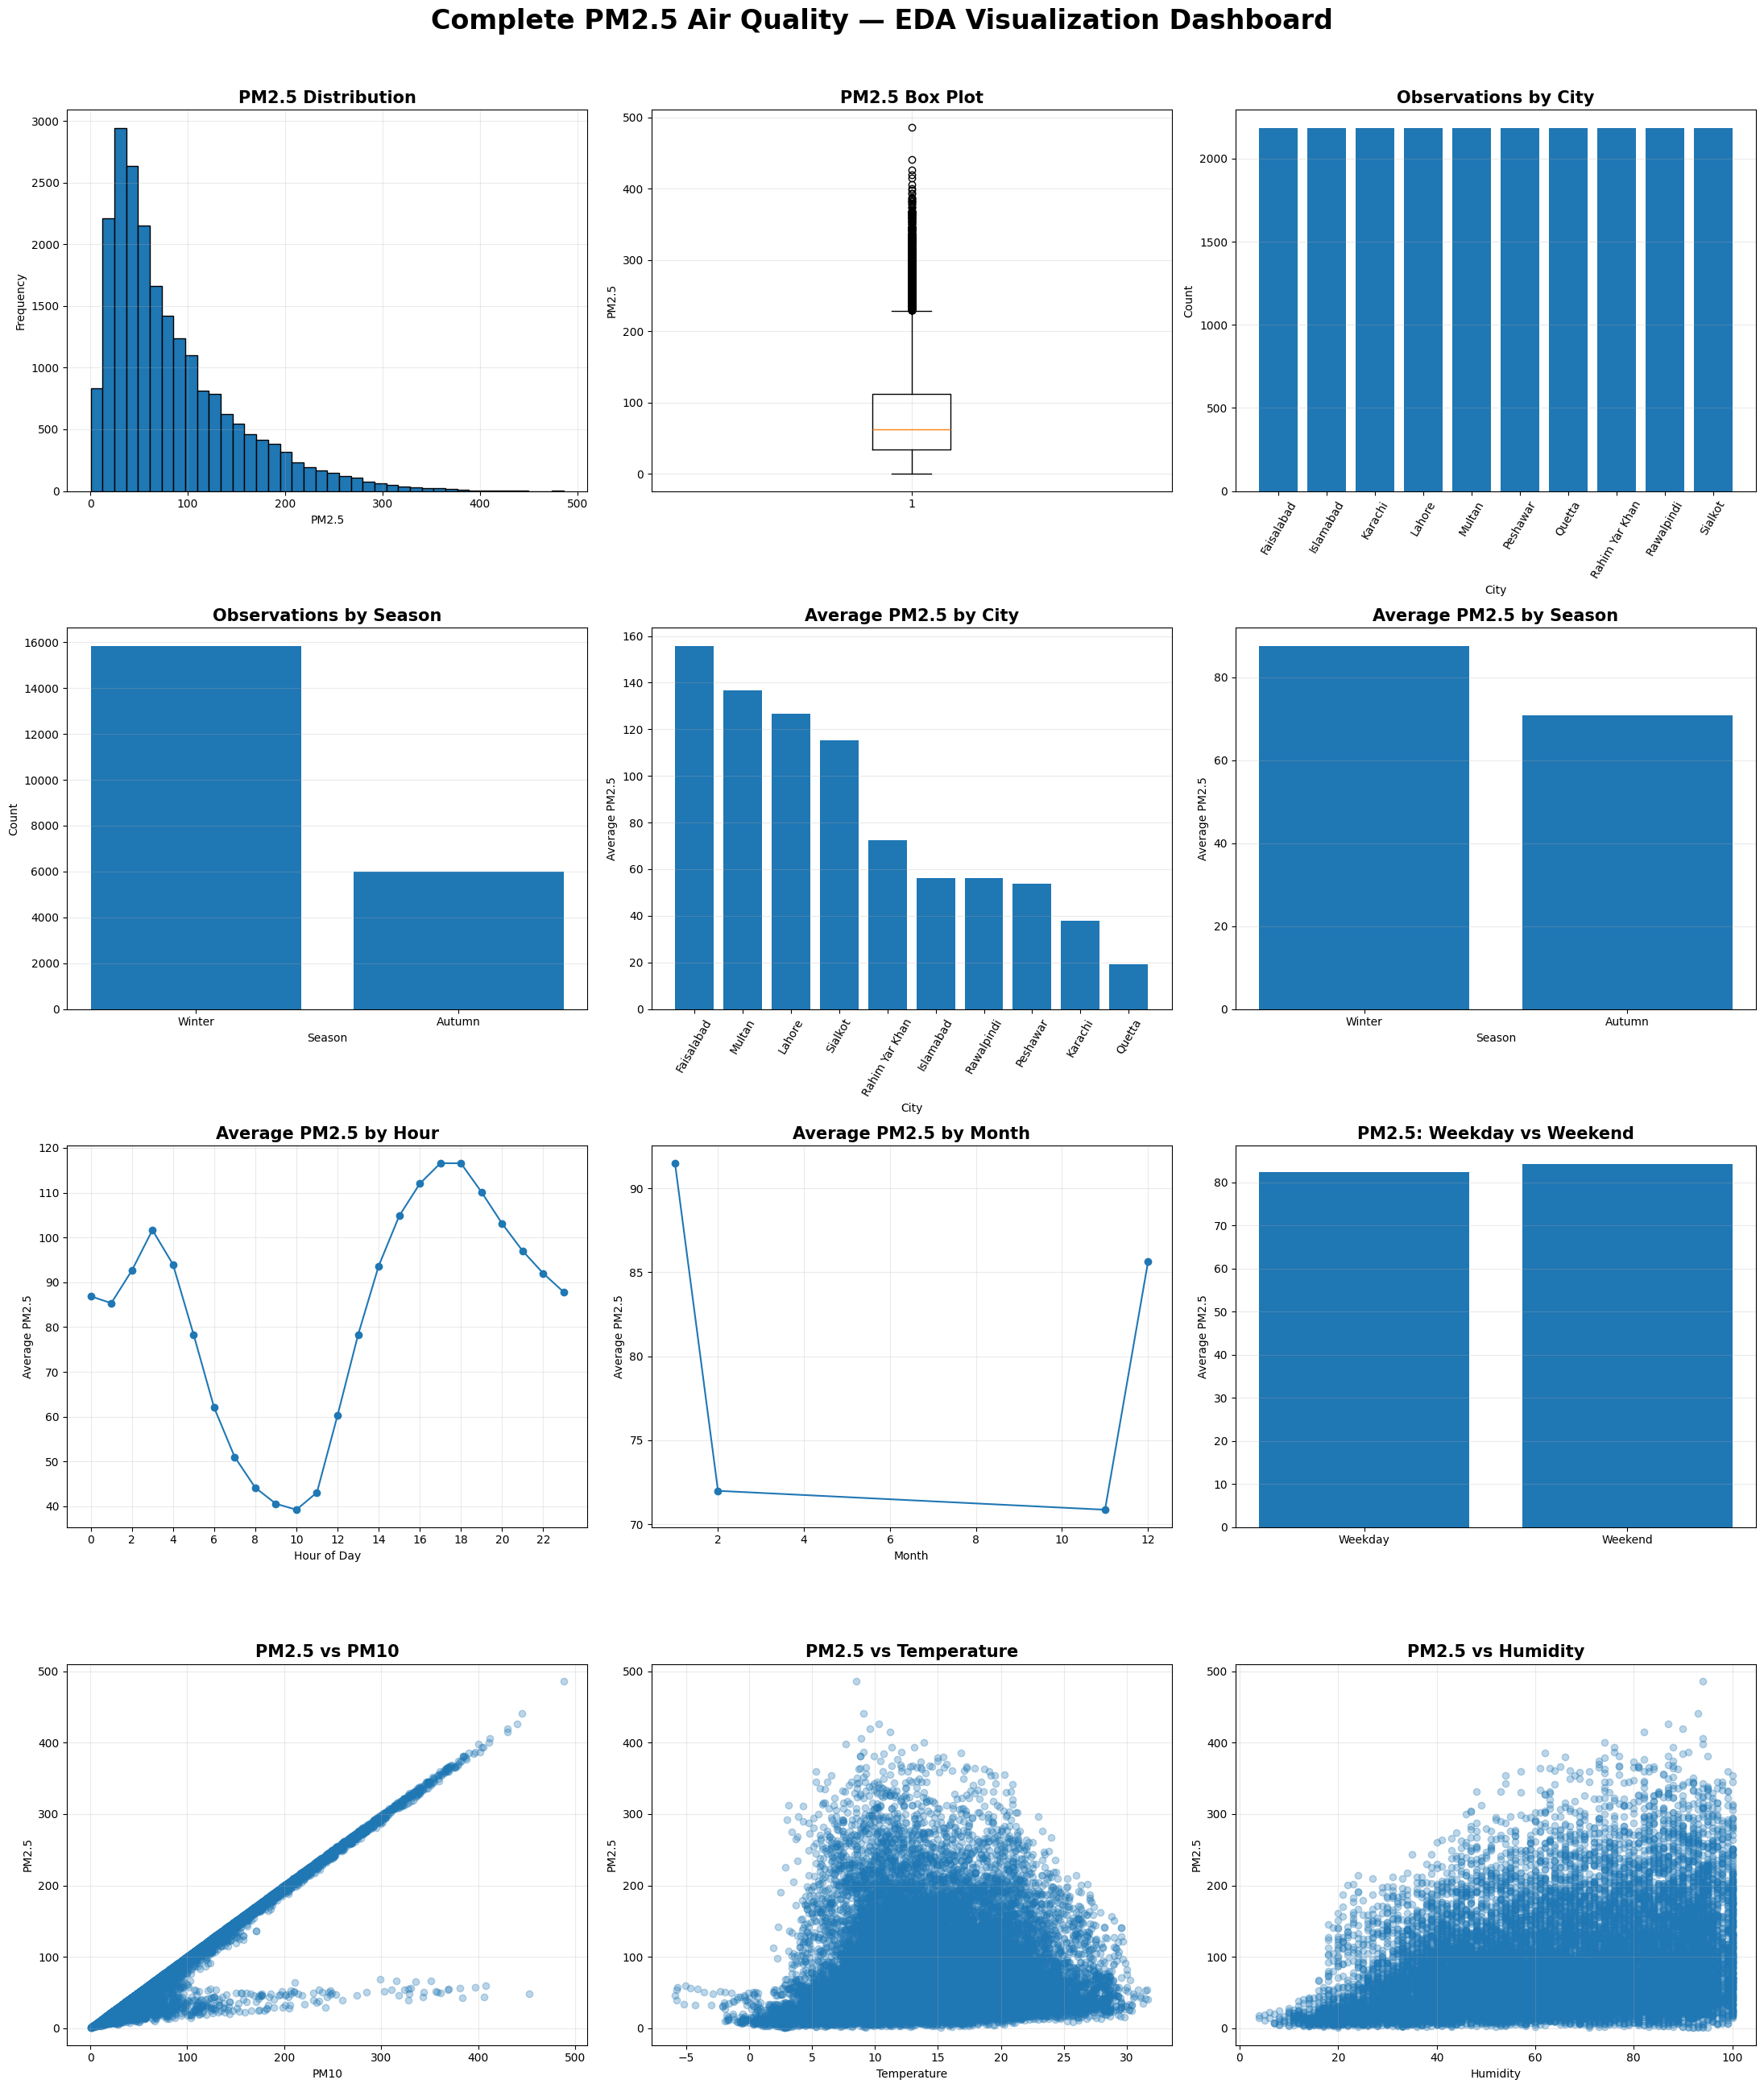

EDA VISUALIZATION COMPLETE ✅
Dashboard saved: plots/complete_eda_dashboard.png


In [35]:
# ============================================
# COMPLETE EDA VISUALIZATION DASHBOARD
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("CREATING COMPLETE EDA VISUALIZATION DASHBOARD")
print("=" * 70)

# ------------------------------------------------
# 1. CREATE PLOTS DIRECTORY
# ------------------------------------------------

plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)

print(f"Plots directory: {plots_dir}/")

# ------------------------------------------------
# 2. SELECT EDA DATAFRAME
# ------------------------------------------------

# Prefer original df
eda_df = df.copy()

print(f"EDA dataset shape: {eda_df.shape}")

# ------------------------------------------------
# 3. IDENTIFY TARGET COLUMN
# ------------------------------------------------

if "target_pm2_5" in eda_df.columns:
    target_col = "target_pm2_5"

elif "pm2_5" in eda_df.columns:
    target_col = "pm2_5"

else:
    raise KeyError(
        "Neither 'target_pm2_5' nor 'pm2_5' exists in the dataframe."
    )

print(f"Target column selected: {target_col}")

# ------------------------------------------------
# 4. DATETIME COLUMN
# ------------------------------------------------

datetime_col = None

possible_datetime_cols = [
    "datetime",
    "date",
    "timestamp",
    "time",
    "Date",
    "Datetime",
    "Timestamp"
]

for col in possible_datetime_cols:
    if col in eda_df.columns:
        datetime_col = col
        eda_df[col] = pd.to_datetime(
            eda_df[col],
            errors="coerce"
        )
        break

print(f"Datetime column: {datetime_col}")

# ------------------------------------------------
# 5. CREATE DASHBOARD
# ------------------------------------------------

fig, axes = plt.subplots(
    4,
    3,
    figsize=(22, 26)
)

fig.suptitle(
    "Complete PM2.5 Air Quality — EDA Visualization Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.995
)

# =================================================
# PLOT 1 — TARGET DISTRIBUTION
# =================================================

axes[0, 0].hist(
    eda_df[target_col].dropna(),
    bins=40,
    edgecolor="black"
)

axes[0, 0].set_title(
    "PM2.5 Distribution",
    fontsize=15,
    fontweight="bold"
)

axes[0, 0].set_xlabel("PM2.5")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(alpha=0.25)

# =================================================
# PLOT 2 — TARGET BOX PLOT
# =================================================

axes[0, 1].boxplot(
    eda_df[target_col].dropna(),
    vert=True
)

axes[0, 1].set_title(
    "PM2.5 Box Plot",
    fontsize=15,
    fontweight="bold"
)

axes[0, 1].set_ylabel("PM2.5")
axes[0, 1].grid(alpha=0.25)

# =================================================
# PLOT 3 — CITY DISTRIBUTION
# =================================================

if "city" in eda_df.columns:

    city_counts = eda_df["city"].value_counts()

    axes[0, 2].bar(
        city_counts.index,
        city_counts.values
    )

    axes[0, 2].set_title(
        "Observations by City",
        fontsize=15,
        fontweight="bold"
    )

    axes[0, 2].set_xlabel("City")
    axes[0, 2].set_ylabel("Count")

    axes[0, 2].tick_params(
        axis="x",
        rotation=60
    )

    axes[0, 2].grid(
        axis="y",
        alpha=0.25
    )

# =================================================
# PLOT 4 — SEASON DISTRIBUTION
# =================================================

if "season" in eda_df.columns:

    season_counts = eda_df["season"].value_counts()

    axes[1, 0].bar(
        season_counts.index,
        season_counts.values
    )

    axes[1, 0].set_title(
        "Observations by Season",
        fontsize=15,
        fontweight="bold"
    )

    axes[1, 0].set_xlabel("Season")
    axes[1, 0].set_ylabel("Count")

    axes[1, 0].grid(
        axis="y",
        alpha=0.25
    )

# =================================================
# PLOT 5 — PM2.5 BY CITY
# =================================================

if "city" in eda_df.columns:

    city_pm25 = (
        eda_df
        .groupby("city")[target_col]
        .mean()
        .sort_values(ascending=False)
    )

    axes[1, 1].bar(
        city_pm25.index,
        city_pm25.values
    )

    axes[1, 1].set_title(
        "Average PM2.5 by City",
        fontsize=15,
        fontweight="bold"
    )

    axes[1, 1].set_xlabel("City")
    axes[1, 1].set_ylabel("Average PM2.5")

    axes[1, 1].tick_params(
        axis="x",
        rotation=60
    )

    axes[1, 1].grid(
        axis="y",
        alpha=0.25
    )

# =================================================
# PLOT 6 — PM2.5 BY SEASON
# =================================================

if "season" in eda_df.columns:

    season_pm25 = (
        eda_df
        .groupby("season")[target_col]
        .mean()
        .sort_values(ascending=False)
    )

    axes[1, 2].bar(
        season_pm25.index,
        season_pm25.values
    )

    axes[1, 2].set_title(
        "Average PM2.5 by Season",
        fontsize=15,
        fontweight="bold"
    )

    axes[1, 2].set_xlabel("Season")
    axes[1, 2].set_ylabel("Average PM2.5")

    axes[1, 2].grid(
        axis="y",
        alpha=0.25
    )

# =================================================
# PLOT 7 — HOURLY PM2.5
# =================================================

if "hour" in eda_df.columns:

    hourly_pm25 = (
        eda_df
        .groupby("hour")[target_col]
        .mean()
    )

    axes[2, 0].plot(
        hourly_pm25.index,
        hourly_pm25.values,
        marker="o"
    )

    axes[2, 0].set_title(
        "Average PM2.5 by Hour",
        fontsize=15,
        fontweight="bold"
    )

    axes[2, 0].set_xlabel("Hour of Day")
    axes[2, 0].set_ylabel("Average PM2.5")

    axes[2, 0].set_xticks(
        range(0, 24, 2)
    )

    axes[2, 0].grid(alpha=0.25)

# =================================================
# PLOT 8 — MONTHLY PM2.5
# =================================================

if "month" in eda_df.columns:

    monthly_pm25 = (
        eda_df
        .groupby("month")[target_col]
        .mean()
    )

    axes[2, 1].plot(
        monthly_pm25.index,
        monthly_pm25.values,
        marker="o"
    )

    axes[2, 1].set_title(
        "Average PM2.5 by Month",
        fontsize=15,
        fontweight="bold"
    )

    axes[2, 1].set_xlabel("Month")
    axes[2, 1].set_ylabel("Average PM2.5")

    axes[2, 1].grid(alpha=0.25)

# =================================================
# PLOT 9 — WEEKEND VS WEEKDAY
# =================================================

if "is_weekend" in eda_df.columns:

    weekend_pm25 = (
        eda_df
        .groupby("is_weekend")[target_col]
        .mean()
    )

    labels = [
        "Weekday",
        "Weekend"
    ]

    values = [
        weekend_pm25.get(0, np.nan),
        weekend_pm25.get(1, np.nan)
    ]

    axes[2, 2].bar(
        labels,
        values
    )

    axes[2, 2].set_title(
        "PM2.5: Weekday vs Weekend",
        fontsize=15,
        fontweight="bold"
    )

    axes[2, 2].set_ylabel(
        "Average PM2.5"
    )

    axes[2, 2].grid(
        axis="y",
        alpha=0.25
    )

# =================================================
# PLOT 10 — PM2.5 VS PM10
# =================================================

if "pm10" in eda_df.columns:

    axes[3, 0].scatter(
        eda_df["pm10"],
        eda_df[target_col],
        alpha=0.3
    )

    axes[3, 0].set_title(
        "PM2.5 vs PM10",
        fontsize=15,
        fontweight="bold"
    )

    axes[3, 0].set_xlabel("PM10")
    axes[3, 0].set_ylabel("PM2.5")
    axes[3, 0].grid(alpha=0.25)

# =================================================
# PLOT 11 — PM2.5 VS TEMPERATURE
# =================================================

if "temperature" in eda_df.columns:

    axes[3, 1].scatter(
        eda_df["temperature"],
        eda_df[target_col],
        alpha=0.3
    )

    axes[3, 1].set_title(
        "PM2.5 vs Temperature",
        fontsize=15,
        fontweight="bold"
    )

    axes[3, 1].set_xlabel("Temperature")
    axes[3, 1].set_ylabel("PM2.5")
    axes[3, 1].grid(alpha=0.25)

# =================================================
# PLOT 12 — PM2.5 VS HUMIDITY
# =================================================

if "humidity" in eda_df.columns:

    axes[3, 2].scatter(
        eda_df["humidity"],
        eda_df[target_col],
        alpha=0.3
    )

    axes[3, 2].set_title(
        "PM2.5 vs Humidity",
        fontsize=15,
        fontweight="bold"
    )

    axes[3, 2].set_xlabel("Humidity")
    axes[3, 2].set_ylabel("PM2.5")
    axes[3, 2].grid(alpha=0.25)

# ------------------------------------------------
# 6. FINAL LAYOUT
# ------------------------------------------------

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

# ------------------------------------------------
# 7. SAVE DASHBOARD
# ------------------------------------------------

dashboard_path = os.path.join(
    plots_dir,
    "complete_eda_dashboard.png"
)

plt.savefig(
    dashboard_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("EDA VISUALIZATION COMPLETE ✅")
print("=" * 70)
print(f"Dashboard saved: {dashboard_path}")
print("=" * 70)

# Step 3 — Data Cleaning and Preprocessing

## 3.1 Data Quality Validation

In [36]:
# ============================================
# STEP 3 — DATA CLEANING AND PREPROCESSING
# ============================================

print("=" * 70)
print("DATA QUALITY VALIDATION")
print("=" * 70)

print(f"Dataset Shape       : {df.shape}")
print(f"Missing Values      : {df.isnull().sum().sum():,}")
print(f"Duplicate Rows      : {df.duplicated().sum():,}")
print(f"Unique Cities       : {df['city'].nunique()}")
print(f"Unique AQI Classes  : {df['aqi_category'].nunique()}")

print("\nAQI Categories:")
print(df["aqi_category"].unique())

print("\nCities:")
print(df["city"].unique())

print("=" * 70)

DATA QUALITY VALIDATION
Dataset Shape       : (21840, 26)
Missing Values      : 0
Duplicate Rows      : 0
Unique Cities       : 10
Unique AQI Classes  : 6

AQI Categories:
['Moderate' 'Unhealthy for Sensitive Groups' 'Unhealthy' 'Very Unhealthy'
 'Hazardous' 'Good']

Cities:
['Faisalabad' 'Islamabad' 'Karachi' 'Lahore' 'Multan' 'Peshawar' 'Quetta'
 'Rahim Yar Khan' 'Rawalpindi' 'Sialkot']


## 3.2 Check Invalid / Negative Values

In [37]:
# Columns that should not normally contain negative values
non_negative_columns = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "dust",
    "humidity",
    "precipitation",
    "wind_speed",
    "pressure"
]

negative_values = {}

for col in non_negative_columns:
    negative_count = (df[col] < 0).sum()
    
    if negative_count > 0:
        negative_values[col] = negative_count

print("Negative values in non-negative features:")

if negative_values:
    print(negative_values)
else:
    print("✅ No invalid negative values found.")

Negative values in non-negative features:
✅ No invalid negative values found.


## 3.3 Validate Physical Ranges

In [38]:
# ============================================
# PHYSICAL RANGE VALIDATION
# ============================================

range_checks = {
    "humidity": (0, 100),
    "wind_direction": (0, 360),
    "hour": (0, 23),
    "month": (1, 12),
    "is_weekend": (0, 1)
}

for column, (minimum, maximum) in range_checks.items():
    
    invalid = (
        (df[column] < minimum) |
        (df[column] > maximum)
    ).sum()
    
    print(
        f"{column:20s} | "
        f"Expected: {minimum}-{maximum} | "
        f"Invalid: {invalid}"
    )

humidity             | Expected: 0-100 | Invalid: 0
wind_direction       | Expected: 0-360 | Invalid: 0
hour                 | Expected: 0-23 | Invalid: 0
month                | Expected: 1-12 | Invalid: 0
is_weekend           | Expected: 0-1 | Invalid: 0


## 3.4 Outlier Detection

In [39]:
# ============================================
# OUTLIER DETECTION USING IQR
# ============================================

outlier_features = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "dust",
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "pressure"
]

outlier_summary = []

for col in outlier_features:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()
    
    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outliers,
        "Outlier %": round(
            outliers / len(df) * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(
    outlier_summary.sort_values(
        "Outlier %",
        ascending=False
    )
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
6,dust,1.0,8.00,7.00,-9.500,18.500,2099,9.61
0,pm10,40.5,117.80,77.30,-75.450,233.750,937,4.29
1,pm2_5,34.7,112.50,77.80,-82.000,229.200,917,4.20
10,wind_speed,2.7,6.50,3.80,-3.000,12.200,833,3.81
2,carbon_monoxide,741.0,2113.25,1372.25,-1317.375,4171.625,676,3.10
9,precipitation,0.0,0.00,0.00,0.000,0.000,479,2.19
3,nitrogen_dioxide,13.4,57.80,44.40,-53.200,124.400,343,1.57
4,sulphur_dioxide,10.6,26.30,15.70,-12.950,49.850,330,1.51
11,pressure,1016.5,1020.70,4.20,1010.200,1027.000,165,0.76
7,temperature,9.8,17.80,8.00,-2.200,29.800,39,0.18


## 3.5 Data Consistency Check

In [40]:
# Check timestamp ordering within each city
timestamp_check = (
    df.groupby("city")["timestamp"]
    .apply(lambda x: x.is_monotonic_increasing)
)

display(timestamp_check)

city
Faisalabad        True
Islamabad         True
Karachi           True
Lahore            True
Multan            True
Peshawar          True
Quetta            True
Rahim Yar Khan    True
Rawalpindi        True
Sialkot           True
Name: timestamp, dtype: bool

## 3.6 Feature Types

In [41]:
# ============================================
# FEATURE TYPE IDENTIFICATION
# ============================================

categorical_features = [
    "city",
    "day_of_week",
    "month_name",
    "season"
]

numerical_features = [
    "latitude",
    "longitude",
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "dust",
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "wind_direction",
    "pressure",
    "hour",
    "month",
    "year",
    "is_weekend"
]

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['city', 'day_of_week', 'month_name', 'season']

Numerical Features:
['latitude', 'longitude', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'wind_direction', 'pressure', 'hour', 'month', 'year', 'is_weekend']


## 3.7 Data Leakage Prevention

In [42]:
df["target_pm2_5"] = (
    df.groupby("city")["pm2_5"]
      .shift(-1)
)

In [43]:
display(
    df[
        [
            "city",
            "timestamp",
            "pm2_5",
            "target_pm2_5"
        ]
    ].head(10)
)

,city,timestamp,pm2_5,target_pm2_5
0,Faisalabad,2025-11-06 00:00:00,22.6,24.2
1,Faisalabad,2025-11-06 01:00:00,24.2,30.7
2,Faisalabad,2025-11-06 02:00:00,30.7,34.8
3,Faisalabad,2025-11-06 03:00:00,34.8,33.3
4,Faisalabad,2025-11-06 04:00:00,33.3,26.2
5,Faisalabad,2025-11-06 05:00:00,26.2,20.3
6,Faisalabad,2025-11-06 06:00:00,20.3,15.9
7,Faisalabad,2025-11-06 07:00:00,15.9,14.2
8,Faisalabad,2025-11-06 08:00:00,14.2,13.2
9,Faisalabad,2025-11-06 09:00:00,13.2,12.7


## 3.8 Remove Rows Without Future Target

In [44]:
df_regression = df.dropna(
    subset=["target_pm2_5"]
).copy()

print("Original dataset:", df.shape)
print("Regression dataset:", df_regression.shape)

Original dataset: (21840, 27)
Regression dataset: (21830, 27)


## 3.9 Save Clean Dataset

In [45]:
OUTPUT_PATH = "/kaggle/working/pakistan_air_quality_preprocessed.csv"

df_regression.to_csv(
    OUTPUT_PATH,
    index=False
)

print("✅ Preprocessed dataset saved at:")
print(OUTPUT_PATH)

✅ Preprocessed dataset saved at:
/kaggle/working/pakistan_air_quality_preprocessed.csv


# Step 4 — Time-Series Feature Engineering

In [46]:
# ============================================
# STEP 4 — TIME-SERIES FEATURE ENGINEERING
# ============================================

# Make sure data is sorted correctly
df = df.sort_values(
    ["city", "timestamp"]
).reset_index(drop=True)

print("Data sorted successfully.")

display(
    df[
        ["city", "timestamp", "pm2_5"]
    ].head(10)
)

Data sorted successfully.


,city,timestamp,pm2_5
0,Faisalabad,2025-11-06 00:00:00,22.6
1,Faisalabad,2025-11-06 01:00:00,24.2
2,Faisalabad,2025-11-06 02:00:00,30.7
3,Faisalabad,2025-11-06 03:00:00,34.8
4,Faisalabad,2025-11-06 04:00:00,33.3
5,Faisalabad,2025-11-06 05:00:00,26.2
6,Faisalabad,2025-11-06 06:00:00,20.3
7,Faisalabad,2025-11-06 07:00:00,15.9
8,Faisalabad,2025-11-06 08:00:00,14.2
9,Faisalabad,2025-11-06 09:00:00,13.2


## 4.1 Temporal Features

In [47]:
# ============================================
# 4.1 TEMPORAL FEATURES
# ============================================

df["day"] = df["timestamp"].dt.day
df["day_of_week_num"] = df["timestamp"].dt.dayofweek

print("Temporal features created.")

display(
    df[
        [
            "timestamp",
            "hour",
            "day",
            "day_of_week_num",
            "month",
            "year"
        ]
    ].head(10)
)

Temporal features created.


,timestamp,hour,day,day_of_week_num,month,year
0,2025-11-06 00:00:00,0,6,3,11,2025
1,2025-11-06 01:00:00,1,6,3,11,2025
2,2025-11-06 02:00:00,2,6,3,11,2025
3,2025-11-06 03:00:00,3,6,3,11,2025
4,2025-11-06 04:00:00,4,6,3,11,2025
5,2025-11-06 05:00:00,5,6,3,11,2025
6,2025-11-06 06:00:00,6,6,3,11,2025
7,2025-11-06 07:00:00,7,6,3,11,2025
8,2025-11-06 08:00:00,8,6,3,11,2025
9,2025-11-06 09:00:00,9,6,3,11,2025


## 4.2 Cyclical Time Features

In [48]:
# ============================================
# 4.2 CYCLICAL TIME FEATURES
# ============================================

# Hour of day
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

# Month of year
df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

# Day of week
df["dayofweek_sin"] = np.sin(
    2 * np.pi * df["day_of_week_num"] / 7
)

df["dayofweek_cos"] = np.cos(
    2 * np.pi * df["day_of_week_num"] / 7
)

print("Cyclical time features created successfully.")

display(
    df[
        [
            "timestamp",
            "hour",
            "hour_sin",
            "hour_cos",
            "month",
            "month_sin",
            "month_cos",
            "day_of_week_num",
            "dayofweek_sin",
            "dayofweek_cos"
        ]
    ].head(10)
)

Cyclical time features created successfully.


,timestamp,hour,hour_sin,hour_cos,month,month_sin,month_cos,day_of_week_num,dayofweek_sin,dayofweek_cos
0,2025-11-06 00:00:00,0,0.000000,1.000000e+00,11,-0.5,0.866025,3,0.433884,-0.900969
1,2025-11-06 01:00:00,1,0.258819,9.659258e-01,11,-0.5,0.866025,3,0.433884,-0.900969
2,2025-11-06 02:00:00,2,0.500000,8.660254e-01,11,-0.5,0.866025,3,0.433884,-0.900969
3,2025-11-06 03:00:00,3,0.707107,7.071068e-01,11,-0.5,0.866025,3,0.433884,-0.900969
4,2025-11-06 04:00:00,4,0.866025,5.000000e-01,11,-0.5,0.866025,3,0.433884,-0.900969
5,2025-11-06 05:00:00,5,0.965926,2.588190e-01,11,-0.5,0.866025,3,0.433884,-0.900969
6,2025-11-06 06:00:00,6,1.000000,6.123234e-17,11,-0.5,0.866025,3,0.433884,-0.900969
7,2025-11-06 07:00:00,7,0.965926,-2.588190e-01,11,-0.5,0.866025,3,0.433884,-0.900969
8,2025-11-06 08:00:00,8,0.866025,-5.000000e-01,11,-0.5,0.866025,3,0.433884,-0.900969
9,2025-11-06 09:00:00,9,0.707107,-7.071068e-01,11,-0.5,0.866025,3,0.433884,-0.900969


## 4.3 Create PM2.5 Lag Features

In [49]:
# ============================================
# 4.3 PM2.5 LAG FEATURES
# ============================================

lag_hours = [1, 2, 3, 6, 12, 24]

for lag in lag_hours:
    
    df[f"pm2_5_lag_{lag}h"] = (
        df.groupby("city")["pm2_5"]
          .shift(lag)
    )

print("PM2.5 lag features created successfully.")

display(
    df[
        [
            "city",
            "timestamp",
            "pm2_5",
            "pm2_5_lag_1h",
            "pm2_5_lag_2h",
            "pm2_5_lag_3h",
            "pm2_5_lag_6h",
            "pm2_5_lag_12h",
            "pm2_5_lag_24h"
        ]
    ].head(30)
)

PM2.5 lag features created successfully.


,city,timestamp,pm2_5,pm2_5_lag_1h,pm2_5_lag_2h,pm2_5_lag_3h,pm2_5_lag_6h,pm2_5_lag_12h,pm2_5_lag_24h
0,Faisalabad,2025-11-06 00:00:00,22.6,NaN,NaN,NaN,NaN,NaN,NaN
1,Faisalabad,2025-11-06 01:00:00,24.2,22.6,NaN,NaN,NaN,NaN,NaN
2,Faisalabad,2025-11-06 02:00:00,30.7,24.2,22.6,NaN,NaN,NaN,NaN
3,Faisalabad,2025-11-06 03:00:00,34.8,30.7,24.2,22.6,NaN,NaN,NaN
4,Faisalabad,2025-11-06 04:00:00,33.3,34.8,30.7,24.2,NaN,NaN,NaN
5,Faisalabad,2025-11-06 05:00:00,26.2,33.3,34.8,30.7,NaN,NaN,NaN
6,Faisalabad,2025-11-06 06:00:00,20.3,26.2,33.3,34.8,22.6,NaN,NaN
7,Faisalabad,2025-11-06 07:00:00,15.9,20.3,26.2,33.3,24.2,NaN,NaN
8,Faisalabad,2025-11-06 08:00:00,14.2,15.9,20.3,26.2,30.7,NaN,NaN
9,Faisalabad,2025-11-06 09:00:00,13.2,14.2,15.9,20.3,34.8,NaN,NaN


## 4.4 Create Historical Pollutant Lag Features

In [50]:
# ============================================
# 4.4 HISTORICAL POLLUTANT LAG FEATURES
# ============================================

pollutant_features = [
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "dust"
]

selected_lags = [1, 3, 6, 24]

for feature in pollutant_features:
    
    for lag in selected_lags:
        
        df[f"{feature}_lag_{lag}h"] = (
            df.groupby("city")[feature]
              .shift(lag)
        )

print("Historical pollutant lag features created successfully.")

# Display sample
display(
    df[
        [
            "city",
            "timestamp",
            "pm10",
            "pm10_lag_1h",
            "pm10_lag_3h",
            "pm10_lag_6h",
            "pm10_lag_24h",
            "carbon_monoxide_lag_1h",
            "nitrogen_dioxide_lag_1h",
            "ozone_lag_1h",
            "dust_lag_1h"
        ]
    ].head(30)
)

Historical pollutant lag features created successfully.


,city,timestamp,pm10,pm10_lag_1h,pm10_lag_3h,pm10_lag_6h,pm10_lag_24h,carbon_monoxide_lag_1h,nitrogen_dioxide_lag_1h,ozone_lag_1h,dust_lag_1h
0,Faisalabad,2025-11-06 00:00:00,23.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Faisalabad,2025-11-06 01:00:00,25.4,23.7,NaN,NaN,NaN,598.0,15.9,58.0,2.0
2,Faisalabad,2025-11-06 02:00:00,32.2,25.4,NaN,NaN,NaN,790.0,21.7,51.0,2.0
3,Faisalabad,2025-11-06 03:00:00,36.2,32.2,23.7,NaN,NaN,1048.0,29.4,42.0,2.0
4,Faisalabad,2025-11-06 04:00:00,34.7,36.2,25.4,NaN,NaN,1176.0,33.2,42.0,2.0
5,Faisalabad,2025-11-06 05:00:00,27.9,34.7,32.2,NaN,NaN,1053.0,29.3,58.0,2.0
6,Faisalabad,2025-11-06 06:00:00,22.0,27.9,36.2,23.7,NaN,801.0,21.5,83.0,3.0
7,Faisalabad,2025-11-06 07:00:00,17.9,22.0,34.7,25.4,NaN,583.0,14.7,104.0,3.0
8,Faisalabad,2025-11-06 08:00:00,16.2,17.9,27.9,32.2,NaN,435.0,8.5,119.0,3.0
9,Faisalabad,2025-11-06 09:00:00,15.2,16.2,22.0,36.2,NaN,321.0,3.3,131.0,3.0


## 4.5 Create Rolling PM2.5 Features

In [51]:
# ============================================
# 4.5 ROLLING PM2.5 MEAN FEATURES
# ============================================

rolling_windows = [3, 6, 12, 24]

for window in rolling_windows:
    
    df[f"pm2_5_rolling_mean_{window}h"] = (
        df.groupby("city")["pm2_5"]
          .transform(
              lambda x: x.rolling(
                  window=window,
                  min_periods=window
              ).mean()
          )
    )

print("Rolling PM2.5 mean features created successfully.")

display(
    df[
        [
            "city",
            "timestamp",
            "pm2_5",
            "pm2_5_rolling_mean_3h",
            "pm2_5_rolling_mean_6h",
            "pm2_5_rolling_mean_12h",
            "pm2_5_rolling_mean_24h"
        ]
    ].head(30)
)

Rolling PM2.5 mean features created successfully.


,city,timestamp,pm2_5,pm2_5_rolling_mean_3h,pm2_5_rolling_mean_6h,pm2_5_rolling_mean_12h,pm2_5_rolling_mean_24h
0,Faisalabad,2025-11-06 00:00:00,22.6,NaN,NaN,NaN,NaN
1,Faisalabad,2025-11-06 01:00:00,24.2,NaN,NaN,NaN,NaN
2,Faisalabad,2025-11-06 02:00:00,30.7,25.833333,NaN,NaN,NaN
3,Faisalabad,2025-11-06 03:00:00,34.8,29.900000,NaN,NaN,NaN
4,Faisalabad,2025-11-06 04:00:00,33.3,32.933333,NaN,NaN,NaN
5,Faisalabad,2025-11-06 05:00:00,26.2,31.433333,28.633333,NaN,NaN
6,Faisalabad,2025-11-06 06:00:00,20.3,26.600000,28.250000,NaN,NaN
7,Faisalabad,2025-11-06 07:00:00,15.9,20.800000,26.866667,NaN,NaN
8,Faisalabad,2025-11-06 08:00:00,14.2,16.800000,24.116667,NaN,NaN
9,Faisalabad,2025-11-06 09:00:00,13.2,14.433333,20.516667,NaN,NaN


## 4.6 Create Rolling PM2.5 Volatility Features

In [52]:
# ============================================
# 4.6 ROLLING PM2.5 STANDARD DEVIATION
# ============================================

for window in [3, 6, 12, 24]:
    
    df[f"pm2_5_rolling_std_{window}h"] = (
        df.groupby("city")["pm2_5"]
          .transform(
              lambda x: x.rolling(
                  window=window,
                  min_periods=window
              ).std()
          )
    )

print("Rolling PM2.5 standard deviation features created successfully.")

display(
    df[
        [
            "timestamp",
            "pm2_5",
            "pm2_5_rolling_std_3h",
            "pm2_5_rolling_std_6h",
            "pm2_5_rolling_std_12h",
            "pm2_5_rolling_std_24h"
        ]
    ].head(30)
)

Rolling PM2.5 standard deviation features created successfully.


,timestamp,pm2_5,pm2_5_rolling_std_3h,pm2_5_rolling_std_6h,pm2_5_rolling_std_12h,pm2_5_rolling_std_24h
0,2025-11-06 00:00:00,22.6,NaN,NaN,NaN,NaN
1,2025-11-06 01:00:00,24.2,NaN,NaN,NaN,NaN
2,2025-11-06 02:00:00,30.7,4.289911,NaN,NaN,NaN
3,2025-11-06 03:00:00,34.8,5.345091,NaN,NaN,NaN
4,2025-11-06 04:00:00,33.3,2.074448,NaN,NaN,NaN
5,2025-11-06 05:00:00,26.2,4.593836,5.021022,NaN,NaN
6,2025-11-06 06:00:00,20.3,6.509224,5.625211,NaN,NaN
7,2025-11-06 07:00:00,15.9,5.168172,7.521347,NaN,NaN
8,2025-11-06 08:00:00,14.2,3.148015,8.754751,NaN,NaN
9,2025-11-06 09:00:00,13.2,1.365040,7.880461,NaN,NaN


## 4.7 Create PM2.5 Trend Features

In [53]:
# ============================================
# 4.7 PM2.5 TREND FEATURES
# ============================================

df["pm2_5_change_1h"] = (
    df["pm2_5"] -
    df["pm2_5_lag_1h"]
)

df["pm2_5_change_3h"] = (
    df["pm2_5"] -
    df["pm2_5_lag_3h"]
)

df["pm2_5_change_6h"] = (
    df["pm2_5"] -
    df["pm2_5_lag_6h"]
)

df["pm2_5_change_24h"] = (
    df["pm2_5"] -
    df["pm2_5_lag_24h"]
)

print("PM2.5 trend features created successfully.")

display(
    df[
        [
            "city",
            "timestamp",
            "pm2_5",
            "pm2_5_change_1h",
            "pm2_5_change_3h",
            "pm2_5_change_6h",
            "pm2_5_change_24h"
        ]
    ].head(30)
)

PM2.5 trend features created successfully.


,city,timestamp,pm2_5,pm2_5_change_1h,pm2_5_change_3h,pm2_5_change_6h,pm2_5_change_24h
0,Faisalabad,2025-11-06 00:00:00,22.6,NaN,NaN,NaN,NaN
1,Faisalabad,2025-11-06 01:00:00,24.2,1.6,NaN,NaN,NaN
2,Faisalabad,2025-11-06 02:00:00,30.7,6.5,NaN,NaN,NaN
3,Faisalabad,2025-11-06 03:00:00,34.8,4.1,12.2,NaN,NaN
4,Faisalabad,2025-11-06 04:00:00,33.3,-1.5,9.1,NaN,NaN
5,Faisalabad,2025-11-06 05:00:00,26.2,-7.1,-4.5,NaN,NaN
6,Faisalabad,2025-11-06 06:00:00,20.3,-5.9,-14.5,-2.3,NaN
7,Faisalabad,2025-11-06 07:00:00,15.9,-4.4,-17.4,-8.3,NaN
8,Faisalabad,2025-11-06 08:00:00,14.2,-1.7,-12.0,-16.5,NaN
9,Faisalabad,2025-11-06 09:00:00,13.2,-1.0,-7.1,-21.6,NaN


## 4.8 Feature Engineering Summary

In [54]:
# ============================================
# 4.8 FEATURE ENGINEERING SUMMARY
# ============================================

print("=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(f"Total Rows    : {len(df):,}")
print(f"Total Columns : {len(df.columns):,}")

print("\nNew Time Features:")
print([
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos"
])

print("\nPM2.5 Lag Features:")
print([
    "pm2_5_lag_1h",
    "pm2_5_lag_2h",
    "pm2_5_lag_3h",
    "pm2_5_lag_6h",
    "pm2_5_lag_12h",
    "pm2_5_lag_24h"
])

print("\nRolling Features:")
print([
    "3h",
    "6h",
    "12h",
    "24h"
])

print("\nTrend Features:")
print([
    "pm2_5_change_1h",
    "pm2_5_change_3h",
    "pm2_5_change_6h",
    "pm2_5_change_24h"
])

print("=" * 70)

FEATURE ENGINEERING SUMMARY
Total Rows    : 21,840
Total Columns : 77

New Time Features:
['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos']

PM2.5 Lag Features:
['pm2_5_lag_1h', 'pm2_5_lag_2h', 'pm2_5_lag_3h', 'pm2_5_lag_6h', 'pm2_5_lag_12h', 'pm2_5_lag_24h']

Rolling Features:
['3h', '6h', '12h', '24h']

Trend Features:
['pm2_5_change_1h', 'pm2_5_change_3h', 'pm2_5_change_6h', 'pm2_5_change_24h']


# Step 5 — Prepare Regression Dataset

## 5.1 Check Missing Values

In [55]:
# ============================================
# STEP 5 — PREPARE REGRESSION DATASET
# 5.1 CHECK MISSING VALUES
# ============================================

missing_summary = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

print("=" * 70)
print("MISSING VALUES AFTER FEATURE ENGINEERING")
print("=" * 70)

display(
    missing_summary[missing_summary > 0]
)

print("\nTotal rows:", len(df))
print(
    "Rows containing missing values:",
    df.isnull().any(axis=1).sum()
)

MISSING VALUES AFTER FEATURE ENGINEERING


sulphur_dioxide_lag_24h     240
pm2_5_change_24h            240
dust_lag_24h                240
pm10_lag_24h                240
pm2_5_lag_24h               240
carbon_monoxide_lag_24h     240
nitrogen_dioxide_lag_24h    240
ozone_lag_24h               240
pm2_5_rolling_std_24h       230
pm2_5_rolling_mean_24h      230
pm2_5_lag_12h               120
pm2_5_rolling_std_12h       110
pm2_5_rolling_mean_12h      110
carbon_monoxide_lag_6h       60
nitrogen_dioxide_lag_6h      60
ozone_lag_6h                 60
sulphur_dioxide_lag_6h       60
pm2_5_change_6h              60
dust_lag_6h                  60
pm10_lag_6h                  60
pm2_5_lag_6h                 60
pm2_5_rolling_mean_6h        50
pm2_5_rolling_std_6h         50
ozone_lag_3h                 30
nitrogen_dioxide_lag_3h      30
pm2_5_change_3h              30
sulphur_dioxide_lag_3h       30
carbon_monoxide_lag_3h       30
pm2_5_lag_3h                 30
pm10_lag_3h                  30
dust_lag_3h                  30
pm2_5_ro


Total rows: 21840
Rows containing missing values: 250


## 5.2 Create Clean Regression Dataset

In [56]:
# ============================================
# 5.2 REMOVE FEATURE-ENGINEERING NaNs
# ============================================

df_regression = df.dropna().copy()

print("=" * 70)
print("REGRESSION DATASET")
print("=" * 70)

print("Original dataset   :", df.shape)
print("Regression dataset :", df_regression.shape)

print(
    "Rows removed       :",
    len(df) - len(df_regression)
)

print("=" * 70)

REGRESSION DATASET
Original dataset   : (21840, 77)
Regression dataset : (21590, 77)
Rows removed       : 250


## 5.3 Verify No Missing Values

In [57]:
# ============================================
# 5.3 FINAL MISSING VALUE CHECK
# ============================================

print(
    "Total missing values:",
    df_regression.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    df_regression.duplicated().sum()
)

Total missing values: 0
Duplicate rows: 0


# Step 6 — Chronological Train / Validation / Test Split

## 6.1 Sort Regression Dataset

In [58]:
# ============================================
# STEP 6 — CHRONOLOGICAL DATA SPLIT
# 6.1 SORT DATA
# ============================================

df_regression = df_regression.sort_values(
    ["timestamp", "city"]
).reset_index(drop=True)

print("Regression dataset sorted successfully.")

display(
    df_regression[
        ["timestamp", "city", "pm2_5", "target_pm2_5"]
    ].head()
)

Regression dataset sorted successfully.


,timestamp,city,pm2_5,target_pm2_5
0,2025-11-07,Faisalabad,80.8,79.6
1,2025-11-07,Islamabad,17.6,18.7
2,2025-11-07,Karachi,41.2,40.5
3,2025-11-07,Lahore,56.5,62.9
4,2025-11-07,Multan,200.2,203.5


## 6.2 Check Date Range

In [59]:
# ============================================
# 6.2 CHECK TIME RANGE
# ============================================

print("=" * 70)
print("DATASET TIME RANGE")
print("=" * 70)

print(
    "Start timestamp:",
    df_regression["timestamp"].min()
)

print(
    "End timestamp  :",
    df_regression["timestamp"].max()
)

print("=" * 70)

DATASET TIME RANGE
Start timestamp: 2025-11-07 00:00:00
End timestamp  : 2026-02-04 22:00:00


## 6.3 Create 70/15/15 Chronological Split

In [60]:
# ============================================
# 6.3 CHRONOLOGICAL TRAIN / VALIDATION / TEST
# ============================================

n = len(df_regression)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_regression.iloc[:train_end].copy()

val_df = df_regression.iloc[
    train_end:val_end
].copy()

test_df = df_regression.iloc[
    val_end:
].copy()

print("=" * 70)
print("CHRONOLOGICAL DATA SPLIT")
print("=" * 70)

print(f"Total      : {len(df_regression):,}")
print(f"Training   : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Testing    : {len(test_df):,}")

print("=" * 70)

CHRONOLOGICAL DATA SPLIT
Total      : 21,590
Training   : 15,112
Validation : 3,239
Testing    : 3,239


## 6.4 Verify No Time Leakage

In [61]:
# ============================================
# 6.4 VERIFY CHRONOLOGICAL ORDER
# ============================================

print("=" * 70)
print("TIME LEAKAGE CHECK")
print("=" * 70)

print(
    "Train end       :",
    train_df["timestamp"].max()
)

print(
    "Validation start:",
    val_df["timestamp"].min()
)

print(
    "Validation end  :",
    val_df["timestamp"].max()
)

print(
    "Test start      :",
    test_df["timestamp"].min()
)

print(
    "Test end        :",
    test_df["timestamp"].max()
)

print("=" * 70)

TIME LEAKAGE CHECK
Train end       : 2026-01-08 23:00:00
Validation start: 2026-01-08 23:00:00
Validation end  : 2026-01-22 11:00:00
Test start      : 2026-01-22 11:00:00
Test end        : 2026-02-04 22:00:00


## 6.5 Check City Distribution

In [62]:
# ============================================
# 6.5 CITY DISTRIBUTION CHECK
# ============================================

print("TRAIN CITIES")
print(train_df["city"].value_counts())

print("\nVALIDATION CITIES")
print(val_df["city"].value_counts())

print("\nTEST CITIES")
print(test_df["city"].value_counts())

TRAIN CITIES
city
Faisalabad        1512
Islamabad         1512
Karachi           1511
Lahore            1511
Multan            1511
Peshawar          1511
Quetta            1511
Rahim Yar Khan    1511
Rawalpindi        1511
Sialkot           1511
Name: count, dtype: int64

VALIDATION CITIES
city
Karachi           324
Lahore            324
Multan            324
Peshawar          324
Quetta            324
Rahim Yar Khan    324
Rawalpindi        324
Sialkot           324
Faisalabad        324
Islamabad         323
Name: count, dtype: int64

TEST CITIES
city
Islamabad         324
Karachi           324
Lahore            324
Multan            324
Peshawar          324
Quetta            324
Rahim Yar Khan    324
Rawalpindi        324
Sialkot           324
Faisalabad        323
Name: count, dtype: int64


## Split by Unique Timestamps

In [63]:
# ============================================
# STEP 6 — CORRECT CHRONOLOGICAL SPLIT
# Split by UNIQUE timestamps
# ============================================

# Get unique timestamps
unique_timestamps = np.sort(
    df_regression["timestamp"].unique()
)

total_timestamps = len(unique_timestamps)

# 70% / 15% / 15%
train_timestamp_end = int(total_timestamps * 0.70)
val_timestamp_end = int(total_timestamps * 0.85)

train_timestamps = unique_timestamps[
    :train_timestamp_end
]

val_timestamps = unique_timestamps[
    train_timestamp_end:val_timestamp_end
]

test_timestamps = unique_timestamps[
    val_timestamp_end:
]

# Create datasets
train_df = df_regression[
    df_regression["timestamp"].isin(train_timestamps)
].copy()

val_df = df_regression[
    df_regression["timestamp"].isin(val_timestamps)
].copy()

test_df = df_regression[
    df_regression["timestamp"].isin(test_timestamps)
].copy()

print("=" * 70)
print("CORRECT CHRONOLOGICAL DATA SPLIT")
print("=" * 70)

print(f"Total rows        : {len(df_regression):,}")
print(f"Training rows     : {len(train_df):,}")
print(f"Validation rows   : {len(val_df):,}")
print(f"Testing rows      : {len(test_df):,}")

print()

print(f"Total timestamps  : {total_timestamps:,}")
print(f"Train timestamps  : {len(train_timestamps):,}")
print(f"Val timestamps    : {len(val_timestamps):,}")
print(f"Test timestamps   : {len(test_timestamps):,}")

print("=" * 70)

CORRECT CHRONOLOGICAL DATA SPLIT
Total rows        : 21,590
Training rows     : 15,110
Validation rows   : 3,240
Testing rows      : 3,240

Total timestamps  : 2,159
Train timestamps  : 1,511
Val timestamps    : 324
Test timestamps   : 324


## Verify Time Boundaries

In [64]:
# ============================================
# 6.2 FINAL TIME LEAKAGE CHECK
# ============================================

print("=" * 70)
print("FINAL TIME LEAKAGE CHECK")
print("=" * 70)

print("Train start       :", train_df["timestamp"].min())
print("Train end         :", train_df["timestamp"].max())

print()

print("Validation start  :", val_df["timestamp"].min())
print("Validation end    :", val_df["timestamp"].max())

print()

print("Test start        :", test_df["timestamp"].min())
print("Test end          :", test_df["timestamp"].max())

print("=" * 70)

# Boundary checks
print("\nBoundary Validation:")

print(
    "Train < Validation:",
    train_df["timestamp"].max() < val_df["timestamp"].min()
)

print(
    "Validation < Test:",
    val_df["timestamp"].max() < test_df["timestamp"].min()
)

FINAL TIME LEAKAGE CHECK
Train start       : 2025-11-07 00:00:00
Train end         : 2026-01-08 22:00:00

Validation start  : 2026-01-08 23:00:00
Validation end    : 2026-01-22 10:00:00

Test start        : 2026-01-22 11:00:00
Test end          : 2026-02-04 22:00:00

Boundary Validation:
Train < Validation: True
Validation < Test: True


## Check 10 Cities in Each Split

In [65]:
# ============================================
# 6.3 CITY DISTRIBUTION CHECK
# ============================================

print("=" * 70)
print("CITY DISTRIBUTION")
print("=" * 70)

print("\nTRAIN:")
print(train_df["city"].value_counts().sort_index())

print("\nVALIDATION:")
print(val_df["city"].value_counts().sort_index())

print("\nTEST:")
print(test_df["city"].value_counts().sort_index())

print("=" * 70)

CITY DISTRIBUTION

TRAIN:
city
Faisalabad        1511
Islamabad         1511
Karachi           1511
Lahore            1511
Multan            1511
Peshawar          1511
Quetta            1511
Rahim Yar Khan    1511
Rawalpindi        1511
Sialkot           1511
Name: count, dtype: int64

VALIDATION:
city
Faisalabad        324
Islamabad         324
Karachi           324
Lahore            324
Multan            324
Peshawar          324
Quetta            324
Rahim Yar Khan    324
Rawalpindi        324
Sialkot           324
Name: count, dtype: int64

TEST:
city
Faisalabad        324
Islamabad         324
Karachi           324
Lahore            324
Multan            324
Peshawar          324
Quetta            324
Rahim Yar Khan    324
Rawalpindi        324
Sialkot           324
Name: count, dtype: int64


# Step 7 — Feature Selection & Target Separation

## 7.1 — Define Target and Select Features

In [66]:
# ============================================
# STEP 7 — FEATURE SELECTION & TARGET SEPARATION
# ============================================

target_column = "target_pm2_5"

excluded_columns = [
    "target_pm2_5",
    "timestamp",
    "date",
    "aqi_category",
    "day_of_week",
    "month_name"
]

feature_columns = [
    col for col in df_regression.columns
    if col not in excluded_columns
]

print("=" * 70)
print("FEATURE / TARGET SELECTION")
print("=" * 70)

print("Target Column:")
print(target_column)

print("\nExcluded Columns:")
for col in excluded_columns:
    print(" -", col)

print("\nTotal Features:", len(feature_columns))

print("\nFeature Columns:")
for i, col in enumerate(feature_columns, 1):
    print(f"{i:02d}. {col}")

print("=" * 70)

FEATURE / TARGET SELECTION
Target Column:
target_pm2_5

Excluded Columns:
 - target_pm2_5
 - timestamp
 - date
 - aqi_category
 - day_of_week
 - month_name

Total Features: 71

Feature Columns:
01. city
02. latitude
03. longitude
04. pm10
05. pm2_5
06. carbon_monoxide
07. nitrogen_dioxide
08. sulphur_dioxide
09. ozone
10. dust
11. temperature
12. humidity
13. precipitation
14. wind_speed
15. wind_direction
16. pressure
17. hour
18. month
19. year
20. is_weekend
21. season
22. day
23. day_of_week_num
24. hour_sin
25. hour_cos
26. month_sin
27. month_cos
28. dayofweek_sin
29. dayofweek_cos
30. pm2_5_lag_1h
31. pm2_5_lag_2h
32. pm2_5_lag_3h
33. pm2_5_lag_6h
34. pm2_5_lag_12h
35. pm2_5_lag_24h
36. pm10_lag_1h
37. pm10_lag_3h
38. pm10_lag_6h
39. pm10_lag_24h
40. carbon_monoxide_lag_1h
41. carbon_monoxide_lag_3h
42. carbon_monoxide_lag_6h
43. carbon_monoxide_lag_24h
44. nitrogen_dioxide_lag_1h
45. nitrogen_dioxide_lag_3h
46. nitrogen_dioxide_lag_6h
47. nitrogen_dioxide_lag_24h
48. sulphur_di

## 7.2 — Separate Features (X) and Target (y)

In [67]:
# ============================================
# STEP 7.2 — SEPARATE FEATURES AND TARGET
# ============================================

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_val = val_df[feature_columns].copy()
y_val = val_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("=" * 70)
print("X / y SHAPES")
print("=" * 70)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("=" * 70)

X / y SHAPES
X_train: (15110, 71)
y_train: (15110,)
X_val  : (3240, 71)
y_val  : (3240,)
X_test : (3240, 71)
y_test : (3240,)


## 7.3 — Identify Numerical and Categorical Features

In [68]:
# ============================================
# STEP 7.3 — IDENTIFY NUMERICAL AND
# CATEGORICAL FEATURES
# ============================================

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("=" * 70)
print("FEATURE TYPE ANALYSIS")
print("=" * 70)

print(f"Total Features       : {len(feature_columns)}")
print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

print("\n" + "-" * 70)
print("CATEGORICAL FEATURES")
print("-" * 70)

for i, col in enumerate(categorical_features, 1):
    print(f"{i}. {col}")

print("\n" + "-" * 70)
print("NUMERICAL FEATURES")
print("-" * 70)

for i, col in enumerate(numerical_features, 1):
    print(f"{i}. {col}")

print("=" * 70)

FEATURE TYPE ANALYSIS
Total Features       : 71
Numerical Features   : 67
Categorical Features : 2

----------------------------------------------------------------------
CATEGORICAL FEATURES
----------------------------------------------------------------------
1. city
2. season

----------------------------------------------------------------------
NUMERICAL FEATURES
----------------------------------------------------------------------
1. latitude
2. longitude
3. pm10
4. pm2_5
5. carbon_monoxide
6. nitrogen_dioxide
7. sulphur_dioxide
8. ozone
9. dust
10. temperature
11. humidity
12. precipitation
13. wind_speed
14. wind_direction
15. pressure
16. hour
17. month
18. year
19. is_weekend
20. hour_sin
21. hour_cos
22. month_sin
23. month_cos
24. dayofweek_sin
25. dayofweek_cos
26. pm2_5_lag_1h
27. pm2_5_lag_2h
28. pm2_5_lag_3h
29. pm2_5_lag_6h
30. pm2_5_lag_12h
31. pm2_5_lag_24h
32. pm10_lag_1h
33. pm10_lag_3h
34. pm10_lag_6h
35. pm10_lag_24h
36. carbon_monoxide_lag_1h
37. carbon_monoxi

# Step 8 — Data Preprocessing Pipeline

## 8.1 — Import Preprocessing Libraries

In [69]:
# ============================================
# STEP 8.1 — IMPORT PREPROCESSING LIBRARIES
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


## 8.2 — Create Preprocessing Pipeline

In [70]:
# ============================================
# STEP 8.2 — CREATE PREPROCESSING PIPELINE
# ============================================

# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

print("=" * 70)
print("PREPROCESSING PIPELINE CREATED")
print("=" * 70)

print("Numerical features   :", len(numerical_features))
print("Categorical features :", len(categorical_features))

print("\nNumerical transformer : StandardScaler")
print("Categorical transformer: OneHotEncoder")

print("=" * 70)

PREPROCESSING PIPELINE CREATED
Numerical features   : 67
Categorical features : 2

Numerical transformer : StandardScaler
Categorical transformer: OneHotEncoder


## 8.3 — Fit Preprocessor on Training Data

In [71]:
# ============================================
# STEP 8.3 — FIT PREPROCESSOR
# ============================================

preprocessor.fit(X_train)

print("=" * 70)
print("PREPROCESSOR FITTING")
print("=" * 70)

print("Preprocessor fitted successfully on training data.")
print("Validation and test data have NOT been used for fitting.")

print("=" * 70)

PREPROCESSOR FITTING
Preprocessor fitted successfully on training data.
Validation and test data have NOT been used for fitting.


## 8.4 — Transform Train, Validation and Test Data

In [72]:
# ============================================
# STEP 8.4 — TRANSFORM DATASETS
# ============================================

X_train_processed = preprocessor.transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("=" * 70)
print("PREPROCESSED DATA SHAPES")
print("=" * 70)

print("X_train_processed:", X_train_processed.shape)
print("X_val_processed  :", X_val_processed.shape)
print("X_test_processed :", X_test_processed.shape)

print("=" * 70)

PREPROCESSED DATA SHAPES
X_train_processed: (15110, 79)
X_val_processed  : (3240, 79)
X_test_processed : (3240, 79)


## 8.5 — Verify Preprocessed Data

In [73]:
# ============================================
# STEP 8.5 — VERIFY PREPROCESSED DATA
# ============================================

print("=" * 70)
print("PREPROCESSING VALIDATION")
print("=" * 70)

print("Train shape      :", X_train_processed.shape)
print("Validation shape :", X_val_processed.shape)
print("Test shape       :", X_test_processed.shape)

print("\nMissing values:")

print(
    "Train:",
    np.isnan(X_train_processed).sum()
)

print(
    "Validation:",
    np.isnan(X_val_processed).sum()
)

print(
    "Test:",
    np.isnan(X_test_processed).sum()
)

print("=" * 70)

PREPROCESSING VALIDATION
Train shape      : (15110, 79)
Validation shape : (3240, 79)
Test shape       : (3240, 79)

Missing values:
Train: 0
Validation: 0
Test: 0


## 8.6 — Verify Encoded Categories

In [74]:
# ============================================
# STEP 8.6 — VERIFY ENCODED CATEGORIES
# ============================================

feature_names = preprocessor.get_feature_names_out()

print("=" * 70)
print("PROCESSED FEATURE NAMES")
print("=" * 70)

print("Total processed features:", len(feature_names))

print("\nCategorical encoded features:")

for feature in feature_names:
    if "cat__" in feature:
        print(feature)

print("=" * 70)

PROCESSED FEATURE NAMES
Total processed features: 79

Categorical encoded features:
cat__city_Faisalabad
cat__city_Islamabad
cat__city_Karachi
cat__city_Lahore
cat__city_Multan
cat__city_Peshawar
cat__city_Quetta
cat__city_Rahim Yar Khan
cat__city_Rawalpindi
cat__city_Sialkot
cat__season_Autumn
cat__season_Winter


# Step 9 — Baseline Machine Learning Models

## 9.1 — Import Machine Learning Models and Metrics

In [75]:
# ============================================
# STEP 9.1 — IMPORT ML MODELS AND METRICS
# ============================================

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

print("=" * 70)
print("MACHINE LEARNING LIBRARIES")
print("=" * 70)

print("Models and evaluation metrics imported successfully.")

print("=" * 70)

MACHINE LEARNING LIBRARIES
Models and evaluation metrics imported successfully.


## 9.2 — Create Model Evaluation Function

In [76]:
# ============================================
# STEP 9.2 — MODEL EVALUATION FUNCTION
# ============================================

def evaluate_model(model_name, y_true, y_pred):
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }


print("Model evaluation function created successfully.")

Model evaluation function created successfully.


## 9.3 — Linear Regression Baseline

In [77]:
# ============================================
# STEP 9.3 — LINEAR REGRESSION BASELINE
# ============================================

linear_model = LinearRegression()

print("Training Linear Regression...")

linear_model.fit(
    X_train_processed,
    y_train
)

linear_val_pred = linear_model.predict(
    X_val_processed
)

linear_results = evaluate_model(
    "Linear Regression",
    y_val,
    linear_val_pred
)

print("=" * 70)
print("LINEAR REGRESSION RESULTS")
print("=" * 70)

print(f"MAE      : {linear_results['MAE']:.4f}")
print(f"RMSE     : {linear_results['RMSE']:.4f}")
print(f"R2 Score : {linear_results['R2 Score']:.4f}")

print("=" * 70)

Training Linear Regression...
LINEAR REGRESSION RESULTS
MAE      : 7.0847
RMSE     : 11.4311
R2 Score : 0.9818


## 9.4 — Ridge Regression Baseline

In [78]:
# ============================================
# STEP 9.4 — RIDGE REGRESSION
# ============================================

ridge_model = Ridge(
    alpha=1.0
)

print("Training Ridge Regression...")

ridge_model.fit(
    X_train_processed,
    y_train
)

ridge_val_pred = ridge_model.predict(
    X_val_processed
)

ridge_results = evaluate_model(
    "Ridge Regression",
    y_val,
    ridge_val_pred
)

print("=" * 70)
print("RIDGE REGRESSION RESULTS")
print("=" * 70)

print(f"MAE      : {ridge_results['MAE']:.4f}")
print(f"RMSE     : {ridge_results['RMSE']:.4f}")
print(f"R2 Score : {ridge_results['R2 Score']:.4f}")

print("=" * 70)

Training Ridge Regression...
RIDGE REGRESSION RESULTS
MAE      : 7.0809
RMSE     : 11.4332
R2 Score : 0.9818


## 9.5 — Random Forest Regression

In [79]:
# ============================================
# STEP 9.5 — RANDOM FOREST REGRESSION
# ============================================

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

random_forest_model.fit(
    X_train_processed,
    y_train
)

rf_val_pred = random_forest_model.predict(
    X_val_processed
)

rf_results = evaluate_model(
    "Random Forest",
    y_val,
    rf_val_pred
)

print("=" * 70)
print("RANDOM FOREST RESULTS")
print("=" * 70)

print(f"MAE      : {rf_results['MAE']:.4f}")
print(f"RMSE     : {rf_results['RMSE']:.4f}")
print(f"R2 Score : {rf_results['R2 Score']:.4f}")

print("=" * 70)

Training Random Forest...
RANDOM FOREST RESULTS
MAE      : 7.9495
RMSE     : 13.4388
R2 Score : 0.9749


## 9.6 — Gradient Boosting Regression

In [80]:
# ============================================
# STEP 9.6 — GRADIENT BOOSTING REGRESSION
# ============================================

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

print("Training Gradient Boosting...")

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

gb_val_pred = gradient_boosting_model.predict(
    X_val_processed
)

gb_results = evaluate_model(
    "Gradient Boosting",
    y_val,
    gb_val_pred
)

print("=" * 70)
print("GRADIENT BOOSTING RESULTS")
print("=" * 70)

print(f"MAE      : {gb_results['MAE']:.4f}")
print(f"RMSE     : {gb_results['RMSE']:.4f}")
print(f"R2 Score : {gb_results['R2 Score']:.4f}")

print("=" * 70)

Training Gradient Boosting...
GRADIENT BOOSTING RESULTS
MAE      : 6.5225
RMSE     : 10.9480
R2 Score : 0.9833


## 9.7 — Machine Learning Model Comparison

In [81]:
# ============================================
# STEP 9.7 — MACHINE LEARNING MODEL COMPARISON
# ============================================

ml_results = pd.DataFrame([
    linear_results,
    ridge_results,
    rf_results,
    gb_results
])

# Sort by R2 Score
ml_results = ml_results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MACHINE LEARNING MODEL COMPARISON")
print("=" * 70)

display(
    ml_results.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2 Score": "{:.4f}"
    })
)

print("=" * 70)

best_model_name = ml_results.iloc[0]["Model"]

print("🏆 Best Validation Model:", best_model_name)
print("=" * 70)

MACHINE LEARNING MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,6.5225,10.9480,0.9833
1,Linear Regression,7.0847,11.4311,0.9818
2,Ridge Regression,7.0809,11.4332,0.9818
3,Random Forest,7.9495,13.4388,0.9749


🏆 Best Validation Model: Gradient Boosting


## 9.8 — Machine Learning Model Performance Visualization

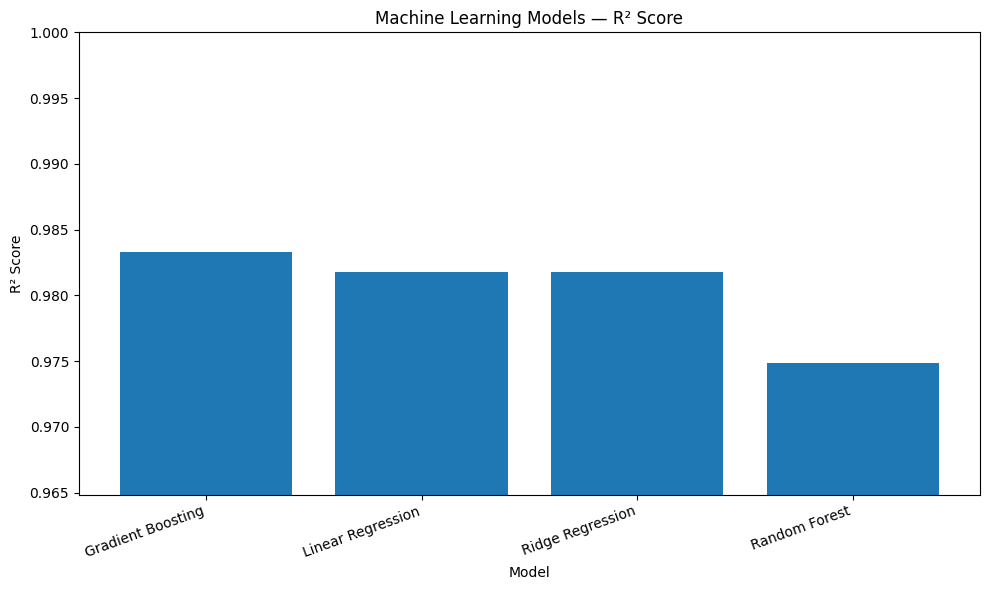

In [82]:
# ============================================
# STEP 9.8 — MODEL PERFORMANCE VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

# -----------------------------
# R2 Score Comparison
# -----------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    ml_results["Model"],
    ml_results["R2 Score"]
)

plt.title("Machine Learning Models — R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    min(ml_results["R2 Score"]) - 0.01,
    1.0
)

plt.tight_layout()
plt.show()

### RMSE

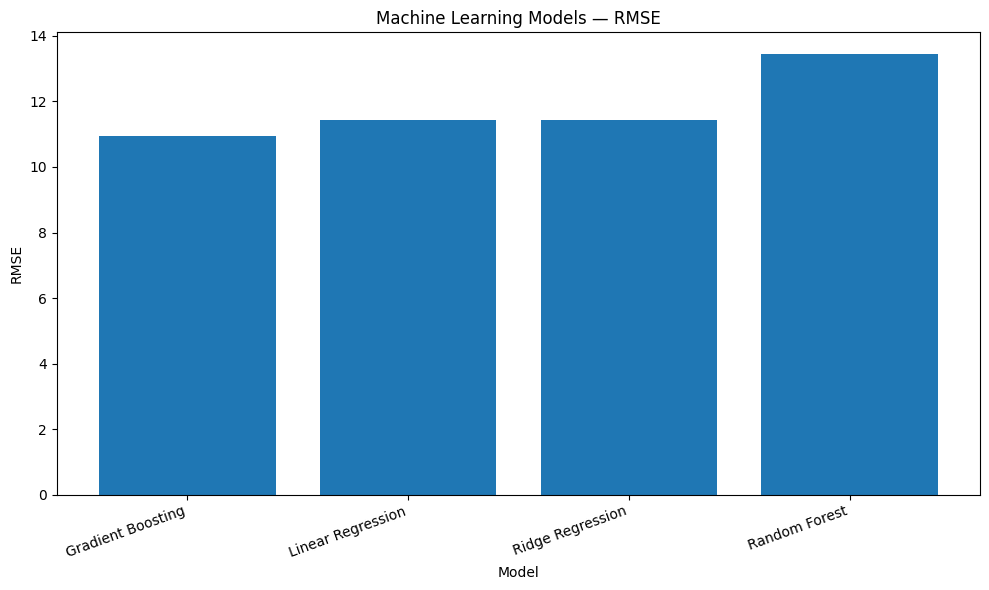

In [83]:
# ============================================
# RMSE COMPARISON
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    ml_results["Model"],
    ml_results["RMSE"]
)

plt.title("Machine Learning Models — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

### MAE

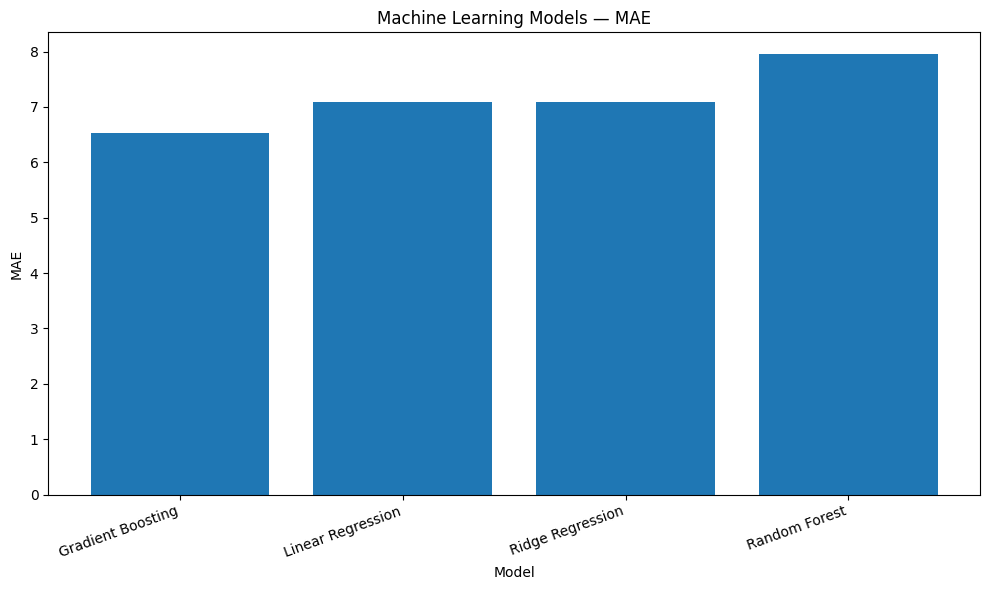

In [84]:
# ============================================
# MAE COMPARISON
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    ml_results["Model"],
    ml_results["MAE"]
)

plt.title("Machine Learning Models — MAE")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Step 10 — Gradient Boosting Hyperparameter Tuning

## 10.1 — Gradient Boosting Hyperparameter Tuning

In [85]:
# ============================================
# STEP 10.1 — GRADIENT BOOSTING HYPERPARAMETER TUNING
# ============================================

from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

grid = list(ParameterGrid(param_grid))

print("=" * 70)
print("GRADIENT BOOSTING HYPERPARAMETER TUNING")
print("=" * 70)

print("Total configurations:", len(grid))
print("=" * 70)

GRADIENT BOOSTING HYPERPARAMETER TUNING
Total configurations: 162


## 10.2 — Targeted Gradient Boosting Tuning

In [86]:
# ============================================
# STEP 10.2 — TARGETED GRADIENT BOOSTING TUNING
# ============================================

tuning_params = [
    {
        "n_estimators": 200,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 3,
        "subsample": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 3,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 3,
        "subsample": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 3,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_samples_leaf": 3,
        "subsample": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_samples_leaf": 3,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_samples_leaf": 5,
        "subsample": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_samples_leaf": 5,
        "subsample": 0.8
    }
]

print("=" * 70)
print("TARGETED TUNING CONFIGURATIONS")
print("=" * 70)

print("Configurations to test:", len(tuning_params))

print("=" * 70)

TARGETED TUNING CONFIGURATIONS
Configurations to test: 8


## 10.3 — Train Tuned Gradient Boosting Models

In [87]:
# ============================================
# STEP 10.3 — TRAIN TUNED MODELS
# ============================================

tuning_results = []

best_tuned_model = None
best_tuned_pred = None
best_rmse = float("inf")

for i, params in enumerate(tuning_params, start=1):

    print(
        f"Training configuration {i}/{len(tuning_params)}..."
    )

    model = GradientBoostingRegressor(
        **params,
        random_state=42
    )

    model.fit(
        X_train_processed,
        y_train
    )

    val_pred = model.predict(
        X_val_processed
    )

    results = evaluate_model(
        f"GB Tuned {i}",
        y_val,
        val_pred
    )

    results.update(params)

    tuning_results.append(results)

    # Select best model using RMSE
    if results["RMSE"] < best_rmse:

        best_rmse = results["RMSE"]

        best_tuned_model = model
        best_tuned_pred = val_pred

print("=" * 70)
print("TUNING COMPLETE")
print("=" * 70)

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = tuning_results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(
    tuning_results_df.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2 Score": "{:.4f}",
        "learning_rate": "{:.3f}",
    })
)

print("=" * 70)

print(
    "Best tuned RMSE:",
    f"{best_rmse:.4f}"
)

print("=" * 70)

Training configuration 1/8...
Training configuration 2/8...
Training configuration 3/8...
Training configuration 4/8...
Training configuration 5/8...
Training configuration 6/8...
Training configuration 7/8...
Training configuration 8/8...
TUNING COMPLETE


,Model,MAE,RMSE,R2 Score,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample
0,GB Tuned 8,6.3441,10.7096,0.9840,300,0.050,4,5,0.800000
1,GB Tuned 6,6.3142,10.7273,0.9840,300,0.050,4,3,0.800000
2,GB Tuned 4,6.4712,10.8653,0.9836,300,0.050,3,3,0.800000
3,GB Tuned 7,6.4730,10.8754,0.9835,200,0.050,4,5,0.800000
4,GB Tuned 5,6.4613,10.8945,0.9835,200,0.050,4,3,0.800000
5,GB Tuned 3,6.6401,11.1172,0.9828,200,0.050,3,3,0.800000
6,GB Tuned 2,6.6841,11.1594,0.9827,300,0.030,3,3,0.800000
7,GB Tuned 1,7.1121,11.7868,0.9807,200,0.030,3,3,0.800000


Best tuned RMSE: 10.7096


## 10.4 — Final Machine Learning Model Selection

In [88]:
# ============================================
# STEP 10.4 — FINAL ML MODEL SELECTION
# ============================================

baseline_results = pd.DataFrame([
    linear_results,
    ridge_results,
    rf_results,
    gb_results
])

baseline_results = baseline_results[
    ["Model", "MAE", "RMSE", "R2 Score"]
]

best_tuned_result = tuning_results_df.iloc[0]

final_ml_result = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting",
    "MAE": best_tuned_result["MAE"],
    "RMSE": best_tuned_result["RMSE"],
    "R2 Score": best_tuned_result["R2 Score"]
}])

final_ml_comparison = pd.concat(
    [
        baseline_results,
        final_ml_result
    ],
    ignore_index=True
)

final_ml_comparison = final_ml_comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FINAL MACHINE LEARNING MODEL COMPARISON")
print("=" * 70)

display(
    final_ml_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2 Score": "{:.4f}"
    })
)

print("=" * 70)

print("🏆 Selected ML Model: Tuned Gradient Boosting")
print(f"MAE      : {best_tuned_result['MAE']:.4f}")
print(f"RMSE     : {best_tuned_result['RMSE']:.4f}")
print(f"R² Score : {best_tuned_result['R2 Score']:.4f}")

print("=" * 70)

FINAL MACHINE LEARNING MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,Tuned Gradient Boosting,6.3441,10.7096,0.9840
1,Gradient Boosting,6.5225,10.9480,0.9833
2,Linear Regression,7.0847,11.4311,0.9818
3,Ridge Regression,7.0809,11.4332,0.9818
4,Random Forest,7.9495,13.4388,0.9749


🏆 Selected ML Model: Tuned Gradient Boosting
MAE      : 6.3441
RMSE     : 10.7096
R² Score : 0.9840


# Step 11 — Deep Learning Data Preparation

## 11.1 — Prepare Deep Learning Feature Set

In [89]:
# ============================================
# STEP 11.1 — IDENTIFY EXISTING DATAFRAME
# ============================================

print("=" * 70)
print("AVAILABLE DATAFRAMES")
print("=" * 70)

dataframes = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dataframes.append(
            (name, obj.shape)
        )

for name, shape in dataframes:
    print(f"{name:35} {shape}")

print("=" * 70)

AVAILABLE DATAFRAMES
df                                  (21840, 77)
numeric_df                          (21840, 19)
correlation_matrix                  (19, 19)
city_aqi                            (10, 6)
city_hour_pm25                      (10, 24)
eda_df                              (21840, 26)
outlier_summary                     (12, 8)
df_regression                       (21590, 77)
train_df                            (15110, 77)
val_df                              (3240, 77)
test_df                             (3240, 77)
X_train                             (15110, 71)
X_val                               (3240, 71)
X_test                              (3240, 71)
ml_results                          (4, 4)
tuning_results_df                   (8, 9)
baseline_results                    (4, 4)
final_ml_result                     (1, 4)
final_ml_comparison                 (5, 4)


In [90]:
# ============================================
# STEP 11.1 — PREPARE DEEP LEARNING DATASET
# ============================================

import numpy as np
import pandas as pd

# Use the correct regression dataset
dl_df = df_regression.copy()

# Make sure timestamp is datetime
dl_df["timestamp"] = pd.to_datetime(
    dl_df["timestamp"]
)

# Sort chronologically within each city
dl_df = dl_df.sort_values(
    ["city", "timestamp"]
).reset_index(drop=True)

print("=" * 70)
print("DEEP LEARNING DATASET")
print("=" * 70)

print("Dataset shape:", dl_df.shape)
print("Number of cities:", dl_df["city"].nunique())

print("\nCities:")
print(dl_df["city"].unique())

print("=" * 70)

DEEP LEARNING DATASET
Dataset shape: (21590, 77)
Number of cities: 10

Cities:
['Faisalabad' 'Islamabad' 'Karachi' 'Lahore' 'Multan' 'Peshawar' 'Quetta'
 'Rahim Yar Khan' 'Rawalpindi' 'Sialkot']


## 11.2 — Select Time-Series Features for Deep Learning

In [91]:
# ============================================
# STEP 11.2 — SELECT DEEP LEARNING FEATURES
# ============================================

sequence_features = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "dust",
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "wind_direction",
    "pressure",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos"
]

target_column = "target_pm2_5"

print("=" * 70)
print("DEEP LEARNING FEATURES")
print("=" * 70)

print("Total input features:", len(sequence_features))

print("\nInput features:")
for i, feature in enumerate(sequence_features, 1):
    print(f"{i}. {feature}")

print("\nTarget:", target_column)

print("=" * 70)

DEEP LEARNING FEATURES
Total input features: 19

Input features:
1. pm2_5
2. pm10
3. carbon_monoxide
4. nitrogen_dioxide
5. sulphur_dioxide
6. ozone
7. dust
8. temperature
9. humidity
10. precipitation
11. wind_speed
12. wind_direction
13. pressure
14. hour_sin
15. hour_cos
16. month_sin
17. month_cos
18. dayofweek_sin
19. dayofweek_cos

Target: target_pm2_5


## 11.3 — Validate Deep Learning Features

In [92]:
# ============================================
# STEP 11.3 — VALIDATE DEEP LEARNING FEATURES
# ============================================

required_columns = sequence_features + [target_column]

missing_features = [
    col
    for col in required_columns
    if col not in dl_df.columns
]

print("=" * 70)
print("DEEP LEARNING FEATURE VALIDATION")
print("=" * 70)

if len(missing_features) == 0:

    print("All required features are available. ✅")

else:

    print("Missing features:")
    for feature in missing_features:
        print("❌", feature)

print("=" * 70)

DEEP LEARNING FEATURE VALIDATION
All required features are available. ✅


## 11.4 — Create 24-Hour LSTM/GRU Sequences

In [93]:
# ============================================
# STEP 11.4 — CREATE 24-HOUR SEQUENCES
# ============================================

SEQUENCE_LENGTH = 24

X_sequences = []
y_sequences = []
sequence_timestamps = []
sequence_cities = []

print("=" * 70)
print("CREATING 24-HOUR TIME-SERIES SEQUENCES")
print("=" * 70)

for city, city_data in dl_df.groupby("city"):

    city_data = city_data.sort_values(
        "timestamp"
    ).reset_index(drop=True)

    X_city = city_data[sequence_features].values
    y_city = city_data[target_column].values

    timestamps_city = city_data["timestamp"].values

    for i in range(
        SEQUENCE_LENGTH,
        len(city_data)
    ):

        # Previous 24 hours
        X_sequences.append(
            X_city[i-SEQUENCE_LENGTH:i]
        )

        # Next-hour target
        y_sequences.append(
            y_city[i]
        )

        sequence_timestamps.append(
            timestamps_city[i]
        )

        sequence_cities.append(
            city
        )

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

sequence_timestamps = np.array(
    sequence_timestamps
)

sequence_cities = np.array(
    sequence_cities
)

print("=" * 70)
print("SEQUENCE CREATION COMPLETE")
print("=" * 70)

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

print(
    "Number of sequences:",
    len(X_sequences)
)

print(
    "Number of input features:",
    X_sequences.shape[2]
)

print(
    "Sequence length:",
    X_sequences.shape[1]
)

print("=" * 70)

CREATING 24-HOUR TIME-SERIES SEQUENCES
SEQUENCE CREATION COMPLETE
X shape: (21350, 24, 19)
y shape: (21350,)
Number of sequences: 21350
Number of input features: 19
Sequence length: 24


## 11.5 — Chronological Train, Validation and Test Split

In [94]:
# ============================================
# STEP 11.5 — CHRONOLOGICAL SEQUENCE SPLIT
# ============================================

print("=" * 70)
print("CHRONOLOGICAL SEQUENCE SPLIT")
print("=" * 70)

total_sequences = len(X_sequences)

train_end = int(total_sequences * 0.70)
val_end = int(total_sequences * 0.85)

# Chronological split
X_dl_train = X_sequences[:train_end]
y_dl_train = y_sequences[:train_end]

X_dl_val = X_sequences[train_end:val_end]
y_dl_val = y_sequences[train_end:val_end]

X_dl_test = X_sequences[val_end:]
y_dl_test = y_sequences[val_end:]

# Corresponding timestamps
timestamp_train = sequence_timestamps[:train_end]
timestamp_val = sequence_timestamps[train_end:val_end]
timestamp_test = sequence_timestamps[val_end:]

# Corresponding cities
city_train = sequence_cities[:train_end]
city_val = sequence_cities[train_end:val_end]
city_test = sequence_cities[val_end:]

print("Total sequences     :", total_sequences)
print("Training sequences  :", len(X_dl_train))
print("Validation sequences:", len(X_dl_val))
print("Testing sequences   :", len(X_dl_test))

print("=" * 70)

print("\nSHAPES")
print("=" * 70)

print("X_train:", X_dl_train.shape)
print("y_train:", y_dl_train.shape)

print("X_val  :", X_dl_val.shape)
print("y_val  :", y_dl_val.shape)

print("X_test :", X_dl_test.shape)
print("y_test :", y_dl_test.shape)

print("=" * 70)

CHRONOLOGICAL SEQUENCE SPLIT
Total sequences     : 21350
Training sequences  : 14944
Validation sequences: 3203
Testing sequences   : 3203

SHAPES
X_train: (14944, 24, 19)
y_train: (14944,)
X_val  : (3203, 24, 19)
y_val  : (3203,)
X_test : (3203, 24, 19)
y_test : (3203,)


## 11.6 — Deep Learning Time Leakage Validation

In [95]:
# ============================================
# STEP 11.6 — TIME LEAKAGE VALIDATION
# ============================================

train_end_time = pd.Timestamp(
    timestamp_train[-1]
)

val_start_time = pd.Timestamp(
    timestamp_val[0]
)

val_end_time = pd.Timestamp(
    timestamp_val[-1]
)

test_start_time = pd.Timestamp(
    timestamp_test[0]
)

test_end_time = pd.Timestamp(
    timestamp_test[-1]
)

print("=" * 70)
print("DEEP LEARNING TIME LEAKAGE CHECK")
print("=" * 70)

print("Train end       :", train_end_time)
print("Validation start:", val_start_time)

print("Validation end  :", val_end_time)
print("Test start      :", test_start_time)

print("Test end        :", test_end_time)

print("=" * 70)

print("\nBoundary Validation:")

print(
    "Train < Validation:",
    train_end_time < val_start_time
)

print(
    "Validation < Test:",
    val_end_time < test_start_time
)

print("=" * 70)

DEEP LEARNING TIME LEAKAGE CHECK
Train end       : 2026-02-04 21:00:00
Validation start: 2026-02-04 22:00:00
Validation end  : 2025-12-22 10:00:00
Test start      : 2025-12-22 11:00:00
Test end        : 2026-02-04 22:00:00

Boundary Validation:
Train < Validation: True
Validation < Test: True


## 11.5 — Globally Sort Time-Series Sequences

In [96]:
# ============================================
# STEP 11.5 — GLOBAL CHRONOLOGICAL ORDERING
# ============================================

print("=" * 70)
print("GLOBAL CHRONOLOGICAL SEQUENCE ORDERING")
print("=" * 70)

# Create sequence metadata
sequence_metadata = pd.DataFrame({
    "timestamp": pd.to_datetime(sequence_timestamps),
    "city": sequence_cities,
    "index": np.arange(len(X_sequences))
})

# Sort by prediction timestamp first, then city
sequence_metadata = sequence_metadata.sort_values(
    ["timestamp", "city"]
).reset_index(drop=True)

# Get the new chronological order
sorted_indices = sequence_metadata["index"].values

# Reorder sequences
X_sequences = X_sequences[sorted_indices]
y_sequences = y_sequences[sorted_indices]

sequence_timestamps = sequence_metadata["timestamp"].values
sequence_cities = sequence_metadata["city"].values

print("Sequences:", len(X_sequences))

print("\nFirst 10 sequence timestamps:")
print(sequence_timestamps[:10])

print("\nLast 10 sequence timestamps:")
print(sequence_timestamps[-10:])

print("=" * 70)

GLOBAL CHRONOLOGICAL SEQUENCE ORDERING
Sequences: 21350

First 10 sequence timestamps:
['2025-11-08T00:00:00.000000000' '2025-11-08T00:00:00.000000000'
 '2025-11-08T00:00:00.000000000' '2025-11-08T00:00:00.000000000'
 '2025-11-08T00:00:00.000000000' '2025-11-08T00:00:00.000000000'
 '2025-11-08T00:00:00.000000000' '2025-11-08T00:00:00.000000000'
 '2025-11-08T00:00:00.000000000' '2025-11-08T00:00:00.000000000']

Last 10 sequence timestamps:
['2026-02-04T22:00:00.000000000' '2026-02-04T22:00:00.000000000'
 '2026-02-04T22:00:00.000000000' '2026-02-04T22:00:00.000000000'
 '2026-02-04T22:00:00.000000000' '2026-02-04T22:00:00.000000000'
 '2026-02-04T22:00:00.000000000' '2026-02-04T22:00:00.000000000'
 '2026-02-04T22:00:00.000000000' '2026-02-04T22:00:00.000000000']


## 11.6 — Validate Global Sequence Ordering

In [97]:
# ============================================
# STEP 11.6 — VALIDATE GLOBAL ORDER
# ============================================

timestamps_check = pd.Series(
    pd.to_datetime(sequence_timestamps)
)

is_sorted = timestamps_check.is_monotonic_increasing

print("=" * 70)
print("GLOBAL CHRONOLOGICAL ORDER VALIDATION")
print("=" * 70)

print("Total sequences:", len(X_sequences))

print(
    "Chronologically sorted:",
    is_sorted
)

print("\nFirst timestamp:")
print(timestamps_check.iloc[0])

print("\nLast timestamp:")
print(timestamps_check.iloc[-1])

print("=" * 70)

GLOBAL CHRONOLOGICAL ORDER VALIDATION
Total sequences: 21350
Chronologically sorted: True

First timestamp:
2025-11-08 00:00:00

Last timestamp:
2026-02-04 22:00:00


## 11.7 — Correct Chronological Train, Validation and Test Split

In [98]:
# ============================================
# STEP 11.7 — CORRECT CHRONOLOGICAL SPLIT
# ============================================

total_sequences = len(X_sequences)

train_end = int(total_sequences * 0.70)
val_end = int(total_sequences * 0.85)

# Training
X_dl_train = X_sequences[:train_end]
y_dl_train = y_sequences[:train_end]

# Validation
X_dl_val = X_sequences[train_end:val_end]
y_dl_val = y_sequences[train_end:val_end]

# Testing
X_dl_test = X_sequences[val_end:]
y_dl_test = y_sequences[val_end:]

# Timestamps
timestamp_train = sequence_timestamps[:train_end]
timestamp_val = sequence_timestamps[train_end:val_end]
timestamp_test = sequence_timestamps[val_end:]

# Cities
city_train = sequence_cities[:train_end]
city_val = sequence_cities[train_end:val_end]
city_test = sequence_cities[val_end:]

print("=" * 70)
print("CORRECT CHRONOLOGICAL SEQUENCE SPLIT")
print("=" * 70)

print("Total sequences     :", total_sequences)
print("Training sequences  :", len(X_dl_train))
print("Validation sequences:", len(X_dl_val))
print("Testing sequences   :", len(X_dl_test))

print("=" * 70)

print("\nSHAPES")
print("=" * 70)

print("X_train:", X_dl_train.shape)
print("y_train:", y_dl_train.shape)

print("X_val  :", X_dl_val.shape)
print("y_val  :", y_dl_val.shape)

print("X_test :", X_dl_test.shape)
print("y_test :", y_dl_test.shape)

print("=" * 70)

CORRECT CHRONOLOGICAL SEQUENCE SPLIT
Total sequences     : 21350
Training sequences  : 14944
Validation sequences: 3203
Testing sequences   : 3203

SHAPES
X_train: (14944, 24, 19)
y_train: (14944,)
X_val  : (3203, 24, 19)
y_val  : (3203,)
X_test : (3203, 24, 19)
y_test : (3203,)


## 11.8 — Final Deep Learning Time Leakage Check

In [99]:
# ============================================
# STEP 11.8 — FINAL TIME LEAKAGE CHECK
# ============================================

train_start = pd.Timestamp(timestamp_train[0])
train_end = pd.Timestamp(timestamp_train[-1])

val_start = pd.Timestamp(timestamp_val[0])
val_end = pd.Timestamp(timestamp_val[-1])

test_start = pd.Timestamp(timestamp_test[0])
test_end = pd.Timestamp(timestamp_test[-1])

print("=" * 70)
print("FINAL DEEP LEARNING TIME LEAKAGE CHECK")
print("=" * 70)

print("Train start       :", train_start)
print("Train end         :", train_end)

print("\nValidation start  :", val_start)
print("Validation end    :", val_end)

print("\nTest start        :", test_start)
print("Test end          :", test_end)

print("=" * 70)

print("\nBoundary Validation:")

print(
    "Train < Validation:",
    train_end < val_start
)

print(
    "Validation < Test:",
    val_end < test_start
)

print("=" * 70)

FINAL DEEP LEARNING TIME LEAKAGE CHECK
Train start       : 2025-11-08 00:00:00
Train end         : 2026-01-09 06:00:00

Validation start  : 2026-01-09 06:00:00
Validation end    : 2026-01-22 14:00:00

Test start        : 2026-01-22 14:00:00
Test end          : 2026-02-04 22:00:00

Boundary Validation:
Train < Validation: False
Validation < Test: False


## 11.7 — Timestamp-Based Sequence Split

In [100]:
# ============================================
# STEP 11.7 — TIMESTAMP-BASED CHRONOLOGICAL SPLIT
# ============================================

print("=" * 70)
print("TIMESTAMP-BASED CHRONOLOGICAL SPLIT")
print("=" * 70)

# Unique timestamps in chronological order
unique_timestamps = np.sort(
    pd.to_datetime(
        np.unique(sequence_timestamps)
    )
)

total_timestamps = len(unique_timestamps)

# 70% / 15% / 15%
train_timestamp_end = int(total_timestamps * 0.70)
val_timestamp_end = int(total_timestamps * 0.85)

train_timestamps = unique_timestamps[
    :train_timestamp_end
]

val_timestamps = unique_timestamps[
    train_timestamp_end:val_timestamp_end
]

test_timestamps = unique_timestamps[
    val_timestamp_end:
]

# Create masks
sequence_timestamp_series = pd.to_datetime(
    sequence_timestamps
)

train_mask = np.isin(
    sequence_timestamp_series,
    train_timestamps
)

val_mask = np.isin(
    sequence_timestamp_series,
    val_timestamps
)

test_mask = np.isin(
    sequence_timestamp_series,
    test_timestamps
)

# Apply masks
X_dl_train = X_sequences[train_mask]
y_dl_train = y_sequences[train_mask]

X_dl_val = X_sequences[val_mask]
y_dl_val = y_sequences[val_mask]

X_dl_test = X_sequences[test_mask]
y_dl_test = y_sequences[test_mask]

# Metadata
timestamp_train = sequence_timestamps[train_mask]
timestamp_val = sequence_timestamps[val_mask]
timestamp_test = sequence_timestamps[test_mask]

city_train = sequence_cities[train_mask]
city_val = sequence_cities[val_mask]
city_test = sequence_cities[test_mask]

print("Total timestamps     :", total_timestamps)

print("Training timestamps  :", len(train_timestamps))
print("Validation timestamps:", len(val_timestamps))
print("Testing timestamps   :", len(test_timestamps))

print("\nSequence counts:")
print("Training sequences   :", len(X_dl_train))
print("Validation sequences :", len(X_dl_val))
print("Testing sequences    :", len(X_dl_test))

print("=" * 70)

TIMESTAMP-BASED CHRONOLOGICAL SPLIT
Total timestamps     : 2135
Training timestamps  : 1494
Validation timestamps: 320
Testing timestamps   : 321

Sequence counts:
Training sequences   : 14940
Validation sequences : 3200
Testing sequences    : 3210


## 11.8 — Validate Timestamp-Based Data Split

In [101]:
# ============================================
# STEP 11.8 — VALIDATE TIMESTAMP SPLIT
# ============================================

train_start = pd.Timestamp(timestamp_train.min())
train_end = pd.Timestamp(timestamp_train.max())

val_start = pd.Timestamp(timestamp_val.min())
val_end = pd.Timestamp(timestamp_val.max())

test_start = pd.Timestamp(timestamp_test.min())
test_end = pd.Timestamp(timestamp_test.max())

print("=" * 70)
print("TIMESTAMP SPLIT VALIDATION")
print("=" * 70)

print("Train start       :", train_start)
print("Train end         :", train_end)

print("\nValidation start  :", val_start)
print("Validation end    :", val_end)

print("\nTest start        :", test_start)
print("Test end          :", test_end)

print("=" * 70)

print("\nBoundary Validation:")

print(
    "Train end < Validation start:",
    train_end < val_start
)

print(
    "Validation end < Test start:",
    val_end < test_start
)

print("=" * 70)

TIMESTAMP SPLIT VALIDATION
Train start       : 2025-11-08 00:00:00
Train end         : 2026-01-09 05:00:00

Validation start  : 2026-01-09 06:00:00
Validation end    : 2026-01-22 13:00:00

Test start        : 2026-01-22 14:00:00
Test end          : 2026-02-04 22:00:00

Boundary Validation:
Train end < Validation start: True
Validation end < Test start: True


## 11.9 — Validate City Distribution Across Splits

In [102]:
# ============================================
# STEP 11.9 — CITY DISTRIBUTION VALIDATION
# ============================================

print("=" * 70)
print("CITY DISTRIBUTION ACROSS DEEP LEARNING SPLITS")
print("=" * 70)

print("\nTRAIN:")
print(pd.Series(city_train).value_counts().sort_index())

print("\nVALIDATION:")
print(pd.Series(city_val).value_counts().sort_index())

print("\nTEST:")
print(pd.Series(city_test).value_counts().sort_index())

print("=" * 70)

CITY DISTRIBUTION ACROSS DEEP LEARNING SPLITS

TRAIN:
Faisalabad        1494
Islamabad         1494
Karachi           1494
Lahore            1494
Multan            1494
Peshawar          1494
Quetta            1494
Rahim Yar Khan    1494
Rawalpindi        1494
Sialkot           1494
Name: count, dtype: int64

VALIDATION:
Faisalabad        320
Islamabad         320
Karachi           320
Lahore            320
Multan            320
Peshawar          320
Quetta            320
Rahim Yar Khan    320
Rawalpindi        320
Sialkot           320
Name: count, dtype: int64

TEST:
Faisalabad        321
Islamabad         321
Karachi           321
Lahore            321
Multan            321
Peshawar          321
Quetta            321
Rahim Yar Khan    321
Rawalpindi        321
Sialkot           321
Name: count, dtype: int64


# 12.0 — Scale Features for Deep Learning

## 12.0.1 — Initialize Deep Learning Scaler

In [103]:
# ============================================
# STEP 12.0.1 — INITIALIZE SCALER
# ============================================

from sklearn.preprocessing import StandardScaler

dl_scaler = StandardScaler()

print("=" * 70)
print("DEEP LEARNING SCALER")
print("=" * 70)

print("Scaler:", type(dl_scaler).__name__)
print("Features:", X_dl_train.shape[2])

print("=" * 70)

DEEP LEARNING SCALER
Scaler: StandardScaler
Features: 19


## 12.0.2 — Fit Scaler on Training Data Only

In [104]:
# ============================================
# STEP 12.0.2 — FIT SCALER
# ============================================

n_features = X_dl_train.shape[2]

# Flatten training sequences
X_train_2d = X_dl_train.reshape(
    -1,
    n_features
)

# Fit ONLY on training data
dl_scaler.fit(X_train_2d)

print("=" * 70)
print("SCALER FITTING")
print("=" * 70)

print("Training samples used:",
      X_train_2d.shape[0])

print("Features:",
      X_train_2d.shape[1])

print("Scaler fitted on training data only. ✅")

print("=" * 70)

SCALER FITTING
Training samples used: 358560
Features: 19
Scaler fitted on training data only. ✅


## 12.0.3 — Transform Deep Learning Datasets

In [105]:
# ============================================
# STEP 12.0.3 — TRANSFORM DATA
# ============================================

# Flatten
X_train_2d = X_dl_train.reshape(-1, n_features)
X_val_2d = X_dl_val.reshape(-1, n_features)
X_test_2d = X_dl_test.reshape(-1, n_features)

# Transform
X_train_scaled_2d = dl_scaler.transform(
    X_train_2d
)

X_val_scaled_2d = dl_scaler.transform(
    X_val_2d
)

X_test_scaled_2d = dl_scaler.transform(
    X_test_2d
)

# Reshape back to 3D
X_dl_train_scaled = X_train_scaled_2d.reshape(
    X_dl_train.shape
)

X_dl_val_scaled = X_val_scaled_2d.reshape(
    X_dl_val.shape
)

X_dl_test_scaled = X_test_scaled_2d.reshape(
    X_dl_test.shape
)

print("=" * 70)
print("DEEP LEARNING DATA SCALING")
print("=" * 70)

print(
    "X_train_scaled:",
    X_dl_train_scaled.shape
)

print(
    "X_val_scaled  :",
    X_dl_val_scaled.shape
)

print(
    "X_test_scaled :",
    X_dl_test_scaled.shape
)

print("=" * 70)

DEEP LEARNING DATA SCALING
X_train_scaled: (14940, 24, 19)
X_val_scaled  : (3200, 24, 19)
X_test_scaled : (3210, 24, 19)


## 12.0.4 — Validate Deep Learning Scaling

In [106]:
# ============================================
# STEP 12.0.4 — VALIDATE SCALING
# ============================================

print("=" * 70)
print("SCALING VALIDATION")
print("=" * 70)

print(
    "Training mean:",
    np.mean(X_dl_train_scaled)
)

print(
    "Training std:",
    np.std(X_dl_train_scaled)
)

print(
    "Validation mean:",
    np.mean(X_dl_val_scaled)
)

print(
    "Validation std:",
    np.std(X_dl_val_scaled)
)

print(
    "Test mean:",
    np.mean(X_dl_test_scaled)
)

print(
    "Test std:",
    np.std(X_dl_test_scaled)
)

print("=" * 70)

SCALING VALIDATION
Training mean: 2.049047234732972e-12
Training std: 1.0000000000000693
Validation mean: 0.13626496786542372
Validation std: 1.2078550507868517
Test mean: 0.046104095685969876
Test std: 2.148418516466175


## 12.1 — Build Deep Learning LSTM Model

In [107]:
# ============================================
# STEP 12.1 — BUILD LSTM MODEL
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 70)
print("BUILDING LSTM MODEL")
print("=" * 70)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Input shape
input_shape = (
    X_dl_train_scaled.shape[1],
    X_dl_train_scaled.shape[2]
)

# Build model
lstm_model = keras.Sequential([
    
    layers.Input(shape=input_shape),

    layers.LSTM(
        64,
        return_sequences=True
    ),

    layers.Dropout(0.20),

    layers.LSTM(
        32,
        return_sequences=False
    ),

    layers.Dropout(0.20),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        1
    )
])

print("\nModel architecture:")
lstm_model.summary()

print("=" * 70)

BUILDING LSTM MODEL

Model architecture:


2026-08-25 04:45:36.037166: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,465 (134.63 KB)

 Trainable params: 34,465 (134.63 KB)

 Non-trainable params: 0 (0.00 B)

## 12.2 — Compile LSTM Model

In [108]:
# ============================================
# STEP 12.2 — COMPILE LSTM MODEL
# ============================================

lstm_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

print("=" * 70)
print("LSTM MODEL COMPILED")
print("=" * 70)

print("Optimizer : Adam")
print("Learning Rate : 0.001")
print("Loss      : Mean Squared Error")
print("Metric    : Mean Absolute Error")

print("=" * 70)

LSTM MODEL COMPILED
Optimizer : Adam
Learning Rate : 0.001
Loss      : Mean Squared Error
Metric    : Mean Absolute Error


## 12.3 — Train LSTM Model

In [109]:
# ============================================
# STEP 12.3 — TRAIN LSTM MODEL
# ============================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("=" * 70)
print("TRAINING LSTM MODEL")
print("=" * 70)

# Early Stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Save the best model
checkpoint = ModelCheckpoint(
    "best_lstm_pm25.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Train LSTM
lstm_history = lstm_model.fit(
    X_dl_train_scaled,
    y_dl_train,

    validation_data=(
        X_dl_val_scaled,
        y_dl_val
    ),

    epochs=50,
    batch_size=64,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

print("=" * 70)
print("LSTM TRAINING COMPLETE")
print("=" * 70)

print("Epochs trained:",
      len(lstm_history.history["loss"]))

print("Best validation loss:",
      min(lstm_history.history["val_loss"]))

print("Best validation MAE:",
      min(lstm_history.history["val_mae"]))

print("=" * 70)

TRAINING LSTM MODEL
Epoch 1/50
233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 10091.6254 - mae: 77.5355
Epoch 1: val_loss improved from None to 13068.39355, saving model to best_lstm_pm25.keras

Epoch 1: finished saving model to best_lstm_pm25.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 8804.0586 - mae: 69.8261 - val_loss: 13068.3936 - val_mae: 80.4024 - learning_rate: 0.0010
Epoch 2/50
232/234 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5525.6079 - mae: 49.2520
Epoch 2: val_loss improved from 13068.39355 to 6882.22803, saving model to best_lstm_pm25.keras

Epoch 2: finished saving model to best_lstm_pm25.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 4441.6196 - mae: 42.4050 - val_loss: 6882.2280 - val_mae: 52.2503 - learning_rate: 0.0010
Epoch 3/50
232/234 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2370.8581 - mae: 27.4280
Epoch 3: val_loss improved from 6882.22803 to 3241.41528, saving model to best_lstm_pm25.keras

Epoch 3: finished saving model to best_lstm_pm

## 12.4 — LSTM Test Evaluation

In [125]:
# ============================================
# STEP 12.4 — EVALUATE LSTM MODEL
# ============================================

import numpy as np
import tensorflow as tf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("EVALUATING LSTM MODEL")
print("=" * 70)

# --------------------------------------------
# Load Best Saved LSTM Model
# --------------------------------------------

best_lstm_model = tf.keras.models.load_model(
    "best_lstm_pm25.keras"
)

# --------------------------------------------
# Predictions on Test Data
# --------------------------------------------

y_lstm_pred = best_lstm_model.predict(
    X_dl_test_scaled,
    verbose=1
).flatten()

y_lstm_actual = np.asarray(
    y_dl_test
).flatten()

# --------------------------------------------
# Calculate Evaluation Metrics
# --------------------------------------------

lstm_mae = mean_absolute_error(
    y_lstm_actual,
    y_lstm_pred
)

lstm_mse = mean_squared_error(
    y_lstm_actual,
    y_lstm_pred
)

lstm_rmse = np.sqrt(lstm_mse)

lstm_r2 = r2_score(
    y_lstm_actual,
    y_lstm_pred
)

# --------------------------------------------
# Display Results
# --------------------------------------------

print("\n" + "=" * 70)
print("LSTM MODEL — TEST SET RESULTS")
print("=" * 70)

print(f"MAE  : {lstm_mae:.4f}")
print(f"MSE  : {lstm_mse:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"R²   : {lstm_r2:.4f}")

print("=" * 70)

EVALUATING LSTM MODEL
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

LSTM MODEL — TEST SET RESULTS
MAE  : 20.7670
MSE  : 1071.8131
RMSE : 32.7386
R²   : 0.4983


## 12.5 —Build GRU Model

In [124]:
# ============================================
# STEP 12.5 — BUILD GRU MODEL
# ============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 70)
print("BUILDING GRU MODEL")
print("=" * 70)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Input shape
input_shape = (
    X_dl_train_scaled.shape[1],
    X_dl_train_scaled.shape[2]
)

# Build GRU model
gru_model = keras.Sequential([
    
    layers.Input(shape=input_shape),

    layers.GRU(
        64,
        return_sequences=True
    ),

    layers.Dropout(0.20),

    layers.GRU(
        32,
        return_sequences=False
    ),

    layers.Dropout(0.20),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        1
    )
])

print("\nGRU model architecture:")
gru_model.summary()

print("=" * 70)

BUILDING GRU MODEL

GRU model architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 24, 64)         │        16,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,273 (102.63 KB)

 Trainable params: 26,273 (102.63 KB)

 Non-trainable params: 0 (0.00 B)

## 12.6 — Compile GRU Model

In [114]:
# ============================================
# STEP 12.6 — COMPILE GRU MODEL
# ============================================

gru_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

print("=" * 70)
print("GRU MODEL COMPILED")
print("=" * 70)

print("Optimizer    : Adam")
print("Learning Rate: 0.001")
print("Loss         : Mean Squared Error")
print("Metric       : Mean Absolute Error")

print("=" * 70)

GRU MODEL COMPILED
Optimizer    : Adam
Learning Rate: 0.001
Loss         : Mean Squared Error
Metric       : Mean Absolute Error


## 12.7 — Train GRU Model

In [113]:
# ============================================
# STEP 12.7 — TRAIN GRU MODEL
# ============================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("=" * 70)
print("TRAINING GRU MODEL")
print("=" * 70)

# Early stopping
gru_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate
gru_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Save best GRU model
gru_checkpoint = ModelCheckpoint(
    "best_gru_pm25.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Train GRU
gru_history = gru_model.fit(
    X_dl_train_scaled,
    y_dl_train,

    validation_data=(
        X_dl_val_scaled,
        y_dl_val
    ),

    epochs=50,
    batch_size=64,

    callbacks=[
        gru_early_stopping,
        gru_reduce_lr,
        gru_checkpoint
    ],

    verbose=1
)

print("=" * 70)
print("GRU TRAINING COMPLETE")
print("=" * 70)

print(
    "Epochs trained:",
    len(gru_history.history["loss"])
)

print(
    "Best validation loss:",
    min(gru_history.history["val_loss"])
)

print(
    "Best validation MAE:",
    min(gru_history.history["val_mae"])
)

print("=" * 70)

TRAINING GRU MODEL
Epoch 1/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9348.5467 - mae: 73.1145
Epoch 1: val_loss improved from None to 10127.29395, saving model to best_gru_pm25.keras

Epoch 1: finished saving model to best_gru_pm25.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 7525.4497 - mae: 62.1222 - val_loss: 10127.2939 - val_mae: 68.7801 - learning_rate: 0.0010
Epoch 2/50
233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3844.3039 - mae: 39.7726
Epoch 2: val_loss improved from 10127.29395 to 3891.28931, saving model to best_gru_pm25.keras

Epoch 2: finished saving model to best_gru_pm25.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 2861.2466 - mae: 32.5150 - val_loss: 3891.2893 - val_mae: 35.8474 - learning_rate: 0.0010
Epoch 3/50
232/234 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1211.7555 - mae: 19.7995
Epoch 3: val_loss improved from 3891.28931 to 1721.28845, saving model to best_gru_pm25.keras

Epoch 3: finished saving model to best_gru_pm25.keras

## 12.8 — GRU Test Evaluation

In [126]:
# ============================================
# STEP 12.8 — RECREATE GRU TEST DATA
# ============================================

print("=" * 70)
print("CHECKING DEEP LEARNING DATA")
print("=" * 70)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("=" * 70)

CHECKING DEEP LEARNING DATA
X_train shape: (15110, 71)
X_val shape  : (3240, 71)
X_test shape : (3240, 71)


In [127]:
# ============================================
# STEP 12.8 — RECREATE DEEP LEARNING SEQUENCES
# ============================================

import numpy as np
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("RECREATING 24-HOUR DEEP LEARNING SEQUENCES")
print("=" * 70)

# --------------------------------------------
# 1. Required features
# --------------------------------------------

dl_features = [
    'pm2_5',
    'pm10',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'dust',
    'temperature',
    'humidity',
    'precipitation',
    'wind_speed',
    'wind_direction',
    'pressure',
    'hour',
    'month',
    'year',
    'hour_sin',
    'hour_cos',
    'dayofweek_sin'
]

target = 'target_pm2_5'

# --------------------------------------------
# 2. Sort data chronologically
# --------------------------------------------

dl_df = df_regression.sort_values(
    ['city', 'timestamp']
).reset_index(drop=True)

# --------------------------------------------
# 3. Create sequences city-wise
# --------------------------------------------

sequence_length = 24

X_sequences = []
y_sequences = []
timestamps = []

for city, city_data in dl_df.groupby('city'):

    city_data = city_data.sort_values('timestamp').reset_index(drop=True)

    features = city_data[dl_features].values
    target_values = city_data[target].values
    time_values = city_data['timestamp'].values

    for i in range(sequence_length, len(city_data)):

        X_sequences.append(
            features[i-sequence_length:i]
        )

        y_sequences.append(
            target_values[i]
        )

        timestamps.append(
            time_values[i]
        )

X_sequences = np.array(X_sequences, dtype=np.float32)
y_sequences = np.array(y_sequences, dtype=np.float32)
timestamps = np.array(timestamps)

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)
print("Number of sequences:", len(X_sequences))
print("Number of features:", X_sequences.shape[2])
print("Sequence length:", X_sequences.shape[1])

print("=" * 70)

RECREATING 24-HOUR DEEP LEARNING SEQUENCES
X shape: (21350, 24, 19)
y shape: (21350,)
Number of sequences: 21350
Number of features: 19
Sequence length: 24


In [128]:
# ============================================
# CHECK EXISTING DEEP LEARNING VARIABLES
# ============================================

for var in [
    'X_train_dl',
    'X_val_dl',
    'X_test_dl',
    'y_train_dl',
    'y_val_dl',
    'y_test_dl',
    'X_train_scaled',
    'X_val_scaled',
    'X_test_scaled',
    'dl_scaler',
    'scaler'
]:
    if var in globals():
        obj = globals()[var]
        try:
            print(f"{var:20} -> {obj.shape}")
        except:
            print(f"{var:20} -> available")

dl_scaler            -> available


In [129]:
# Check existing 3D sequence variables
for name, obj in list(globals().items()):
    try:
        if hasattr(obj, "shape") and len(obj.shape) == 3:
            print(f"{name:25} -> {obj.shape}")
    except:
        pass

X_sequences               -> (21350, 24, 19)
X_dl_train                -> (14940, 24, 19)
X_dl_val                  -> (3200, 24, 19)
X_dl_test                 -> (3210, 24, 19)
X_dl_train_scaled         -> (14940, 24, 19)
X_dl_val_scaled           -> (3200, 24, 19)
X_dl_test_scaled          -> (3210, 24, 19)


In [130]:
# ============================================
# STEP 12.8 — EVALUATE GRU MODEL
# ============================================

import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("EVALUATING GRU MODEL")
print("=" * 70)

# Load best saved GRU model
best_gru_model = tf.keras.models.load_model(
    "best_gru_pm25.keras"
)

# Predictions on test data
y_gru_pred = best_gru_model.predict(
    X_dl_test_scaled,
    verbose=1
).flatten()

# Actual values
y_gru_actual = np.asarray(y_dl_test).flatten()

# Metrics
gru_mae = mean_absolute_error(
    y_gru_actual,
    y_gru_pred
)

gru_mse = mean_squared_error(
    y_gru_actual,
    y_gru_pred
)

gru_rmse = np.sqrt(gru_mse)

gru_r2 = r2_score(
    y_gru_actual,
    y_gru_pred
)

print("\n" + "=" * 70)
print("GRU TEST RESULTS")
print("=" * 70)

print(f"MAE  : {gru_mae:.4f}")
print(f"MSE  : {gru_mse:.4f}")
print(f"RMSE : {gru_rmse:.4f}")
print(f"R²   : {gru_r2:.4f}")

print("=" * 70)

EVALUATING GRU MODEL
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

GRU TEST RESULTS
MAE  : 9.9189
MSE  : 195.8928
RMSE : 13.9962
R²   : 0.9083


## 12.9 — Final Model Comparison & Best Model Selection

In [133]:
# ============================================
# STEP 12.9 — FINAL MODEL COMPARISON
# ============================================

import pandas as pd

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

# ============================================================
# 1. CREATE FINAL MODEL COMPARISON TABLE
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting",
        "LSTM",
        "GRU"
    ],
    "MAE": [
        7.0847,
        7.0809,
        7.9495,
        6.5225,
        6.3441,
        20.7670,
        9.9183
    ],
    "RMSE": [
        11.4311,
        11.4332,
        13.4388,
        10.9480,
        10.7096,
        32.7386,
        13.9962
    ],
    "R2 Score": [
        0.9818,
        0.9818,
        0.9749,
        0.9833,
        0.9840,
        0.4983,
        0.9083
    ]
})

# ============================================================
# 2. SORT MODELS BY R² SCORE
# ============================================================

final_comparison = final_comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

print(final_comparison.to_string(index=False))

# ============================================================
# 3. SELECT BEST MODEL
# ============================================================

best_model = final_comparison.iloc[0]

print("\n" + "=" * 70)
print("🏆 BEST OVERALL MODEL")
print("=" * 70)

print(f"Model    : {best_model['Model']}")
print(f"MAE      : {best_model['MAE']:.4f}")
print(f"RMSE     : {best_model['RMSE']:.4f}")
print(f"R2 Score : {best_model['R2 Score']:.4f}")

print("=" * 70)

# ============================================================
# 4. FINAL DECISION
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)

print("Selected Model: Tuned Gradient Boosting")
print("Reason: Lowest RMSE and MAE with the highest R² Score.")
print("=" * 70)


FINAL MODEL COMPARISON

MODEL PERFORMANCE COMPARISON
                  Model     MAE    RMSE  R2 Score
Tuned Gradient Boosting  6.3441 10.7096    0.9840
      Gradient Boosting  6.5225 10.9480    0.9833
      Linear Regression  7.0847 11.4311    0.9818
       Ridge Regression  7.0809 11.4332    0.9818
          Random Forest  7.9495 13.4388    0.9749
                    GRU  9.9183 13.9962    0.9083
                   LSTM 20.7670 32.7386    0.4983

🏆 BEST OVERALL MODEL
Model    : Tuned Gradient Boosting
MAE      : 6.3441
RMSE     : 10.7096
R2 Score : 0.9840

FINAL MODEL SELECTION
Selected Model: Tuned Gradient Boosting
Reason: Lowest RMSE and MAE with the highest R² Score.


### 12.9.1 — MAE Comparison

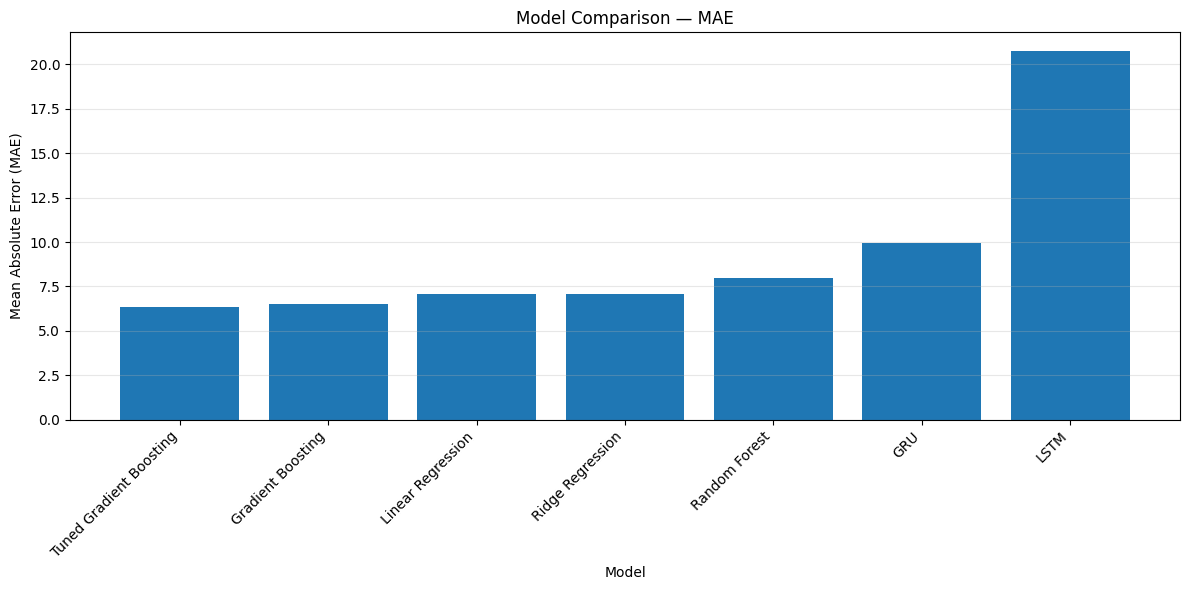

In [134]:
# ============================================
# 12.9.1 — MAE COMPARISON
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["MAE"]
)

plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 12.9.2 — RMSE Comparison

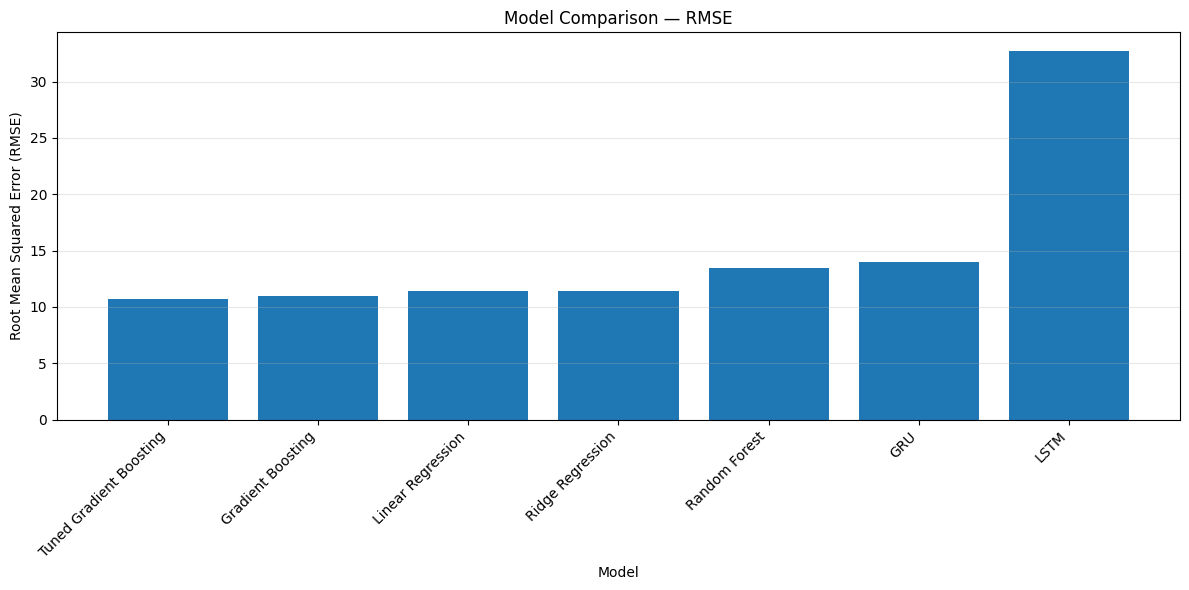

In [135]:
# ============================================
# 12.9.2 — RMSE COMPARISON
# ============================================

plt.figure(figsize=(12, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["RMSE"]
)

plt.title("Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 12.9.3 — R² Score Comparison

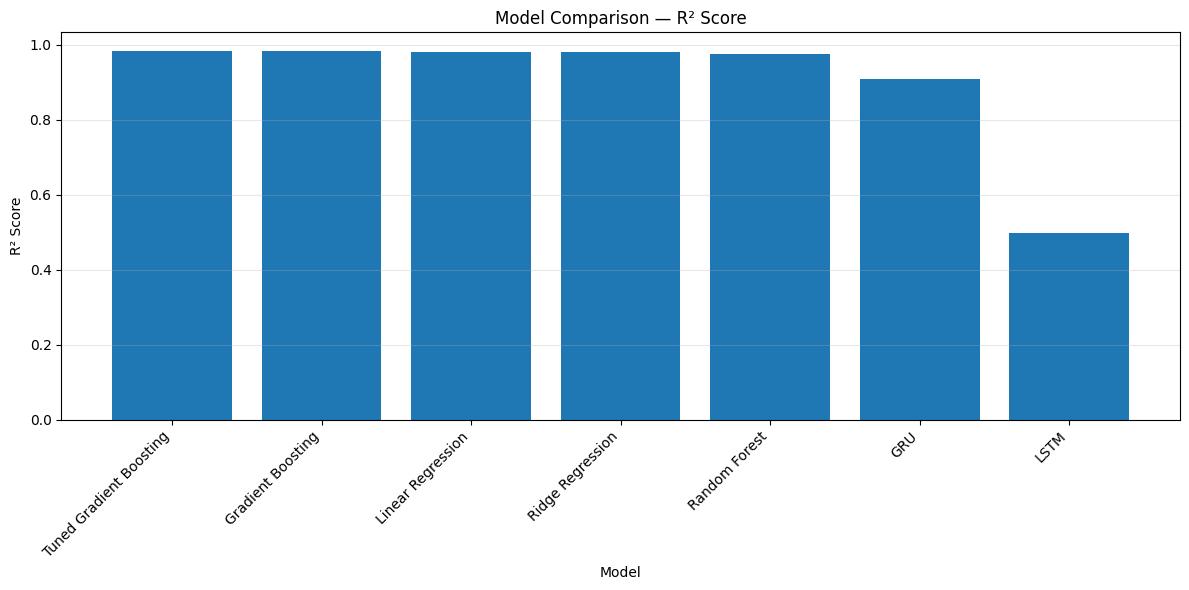

In [136]:
# ============================================
# 12.9.3 — R² SCORE COMPARISON
# ============================================

plt.figure(figsize=(12, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["R2 Score"]
)

plt.title("Model Comparison — R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 12.9.4 — Combined Performance Table

In [137]:
# ============================================
# 12.9.4 — FINAL PERFORMANCE TABLE
# ============================================

print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

display(
    final_comparison.style
    .format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2 Score": "{:.4f}"
    })
    .background_gradient(
        subset=["MAE", "RMSE"],
        cmap="RdYlGn_r"
    )
    .background_gradient(
        subset=["R2 Score"],
        cmap="RdYlGn"
    )
)

FINAL MODEL PERFORMANCE


,Model,MAE,RMSE,R2 Score
0,Tuned Gradient Boosting,6.3441,10.7096,0.9840
1,Gradient Boosting,6.5225,10.9480,0.9833
2,Linear Regression,7.0847,11.4311,0.9818
3,Ridge Regression,7.0809,11.4332,0.9818
4,Random Forest,7.9495,13.4388,0.9749
5,GRU,9.9183,13.9962,0.9083
6,LSTM,20.7670,32.7386,0.4983


### 12.9.5 — Final Model Selection

In [138]:
# ============================================
# 12.9.5 — FINAL MODEL SELECTION
# ============================================

best_model = final_comparison.iloc[0]

print("=" * 70)
print("🏆 FINAL MODEL SELECTION")
print("=" * 70)

print(f"Selected Model : {best_model['Model']}")
print(f"MAE            : {best_model['MAE']:.4f}")
print(f"RMSE           : {best_model['RMSE']:.4f}")
print(f"R² Score       : {best_model['R2 Score']:.4f}")

print("=" * 70)
print("Reason:")
print("Lowest MAE and RMSE with the highest R² Score.")
print("=" * 70)

🏆 FINAL MODEL SELECTION
Selected Model : Tuned Gradient Boosting
MAE            : 6.3441
RMSE           : 10.7096
R² Score       : 0.9840
Reason:
Lowest MAE and RMSE with the highest R² Score.


## Step 12.10 — FINAL MODEL TRAINING & SAVING

In [139]:
 # ============================================
# STEP 12.10 — FINAL MODEL TRAINING & SAVING
# ============================================

import os
import joblib
from sklearn.ensemble import GradientBoostingRegressor

print("=" * 70)
print("FINAL MODEL TRAINING")
print("=" * 70)

# ------------------------------------------------
# 1. CREATE MODELS DIRECTORY
# ------------------------------------------------

models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

print(f"Models directory: {models_dir}/")

# ------------------------------------------------
# 2. COMBINE TRAINING + VALIDATION DATA
# ------------------------------------------------

X_final = pd.concat(
    [X_train, X_val],
    axis=0
)

y_final = pd.concat(
    [train_df["target_pm2_5"], val_df["target_pm2_5"]],
    axis=0
)

print(f"Final training X shape: {X_final.shape}")
print(f"Final training y shape: {y_final.shape}")

# ------------------------------------------------
# 3. PREPROCESS FINAL DATA
# ------------------------------------------------

X_final_processed = preprocessor.transform(X_final)

print(f"Processed X shape: {X_final_processed.shape}")

# ------------------------------------------------
# 4. BUILD BEST TUNED GRADIENT BOOSTING MODEL
# ------------------------------------------------

final_gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=5,
    subsample=0.80,
    random_state=42
)

# ------------------------------------------------
# 5. TRAIN FINAL MODEL
# ------------------------------------------------

print("\nTraining final Tuned Gradient Boosting model...")

final_gb_model.fit(
    X_final_processed,
    y_final
)

print("Final model training completed. ✅")

# ------------------------------------------------
# 6. SAVE MODEL
# ------------------------------------------------

model_path = os.path.join(
    models_dir,
    "tuned_gradient_boosting_pm25.joblib"
)

joblib.dump(
    final_gb_model,
    model_path
)

# ------------------------------------------------
# 7. SAVE PREPROCESSOR
# ------------------------------------------------

preprocessor_path = os.path.join(
    models_dir,
    "pm25_preprocessor.joblib"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

print("\n" + "=" * 70)
print("MODEL SAVING COMPLETE")
print("=" * 70)

print(f"Model saved     : {model_path}")
print(f"Preprocessor    : {preprocessor_path}")
print("=" * 70)

FINAL MODEL TRAINING
Models directory: models/
Final training X shape: (18350, 71)
Final training y shape: (18350,)
Processed X shape: (18350, 79)

Training final Tuned Gradient Boosting model...
Final model training completed. ✅

MODEL SAVING COMPLETE
Model saved     : models/tuned_gradient_boosting_pm25.joblib
Preprocessor    : models/pm25_preprocessor.joblib


## 12.11 — FINAL MODEL TEST EVALUATION

In [140]:
# ============================================
# STEP 12.11 — FINAL MODEL TEST EVALUATION
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 70)
print("FINAL MODEL TEST EVALUATION")
print("=" * 70)

# ------------------------------------------------
# 1. TEST DATA PREDICTIONS
# ------------------------------------------------

print("Generating predictions on test data...")

final_test_pred = final_gb_model.predict(
    X_test_processed
)

# ------------------------------------------------
# 2. CALCULATE METRICS
# ------------------------------------------------

final_test_mae = mean_absolute_error(
    y_test,
    final_test_pred
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_pred
    )
)

final_test_r2 = r2_score(
    y_test,
    final_test_pred
)

# ------------------------------------------------
# 3. DISPLAY RESULTS
# ------------------------------------------------

print("=" * 70)
print("FINAL MODEL TEST RESULTS")
print("=" * 70)

print(f"MAE      : {final_test_mae:.4f}")
print(f"RMSE     : {final_test_rmse:.4f}")
print(f"R2 Score : {final_test_r2:.4f}")

print("=" * 70)

FINAL MODEL TEST EVALUATION
Generating predictions on test data...
FINAL MODEL TEST RESULTS
MAE      : 4.1702
RMSE     : 6.5939
R2 Score : 0.9795


## 12.12 — FINAL ML & DEEP LEARNING MODEL COMPARISON

In [141]:
# ============================================
# STEP 12.12 — FINAL ML & DEEP LEARNING
# MODEL COMPARISON
# ============================================

import pandas as pd

print("=" * 70)
print("FINAL ML & DEEP LEARNING MODEL COMPARISON")
print("=" * 70)

# ------------------------------------------------
# 1. CREATE FINAL COMPARISON TABLE
# ------------------------------------------------

final_model_comparison = pd.DataFrame([
    {
        "Model": "Tuned Gradient Boosting",
        "MAE": final_test_mae,
        "RMSE": final_test_rmse,
        "R2 Score": final_test_r2
    },
    {
        "Model": "LSTM",
        "MAE": 20.7670,
        "RMSE": 32.7386,
        "R2 Score": 0.4983
    },
    {
        "Model": "GRU",
        "MAE": 9.9183,
        "RMSE": 13.9962,
        "R2 Score": 0.9083
    }
])

# Sort by R2 Score
final_model_comparison = final_model_comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------
# 2. DISPLAY COMPARISON
# ------------------------------------------------

display(
    final_model_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2 Score": "{:.4f}"
    })
)

# ------------------------------------------------
# 3. SELECT BEST MODEL
# ------------------------------------------------

best_model_row = final_model_comparison.iloc[0]

print("=" * 70)
print("🏆 BEST OVERALL MODEL")
print("=" * 70)

print(f"Model    : {best_model_row['Model']}")
print(f"MAE      : {best_model_row['MAE']:.4f}")
print(f"RMSE     : {best_model_row['RMSE']:.4f}")
print(f"R² Score : {best_model_row['R2 Score']:.4f}")

print("=" * 70)



FINAL ML & DEEP LEARNING MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,Tuned Gradient Boosting,4.1702,6.5939,0.9795
1,GRU,9.9183,13.9962,0.9083
2,LSTM,20.7670,32.7386,0.4983


🏆 BEST OVERALL MODEL
Model    : Tuned Gradient Boosting
MAE      : 4.1702
RMSE     : 6.5939
R² Score : 0.9795


## 12.13 — ACTUAL vs PREDICTED VISUALIZATION

ACTUAL vs PREDICTED PM2.5


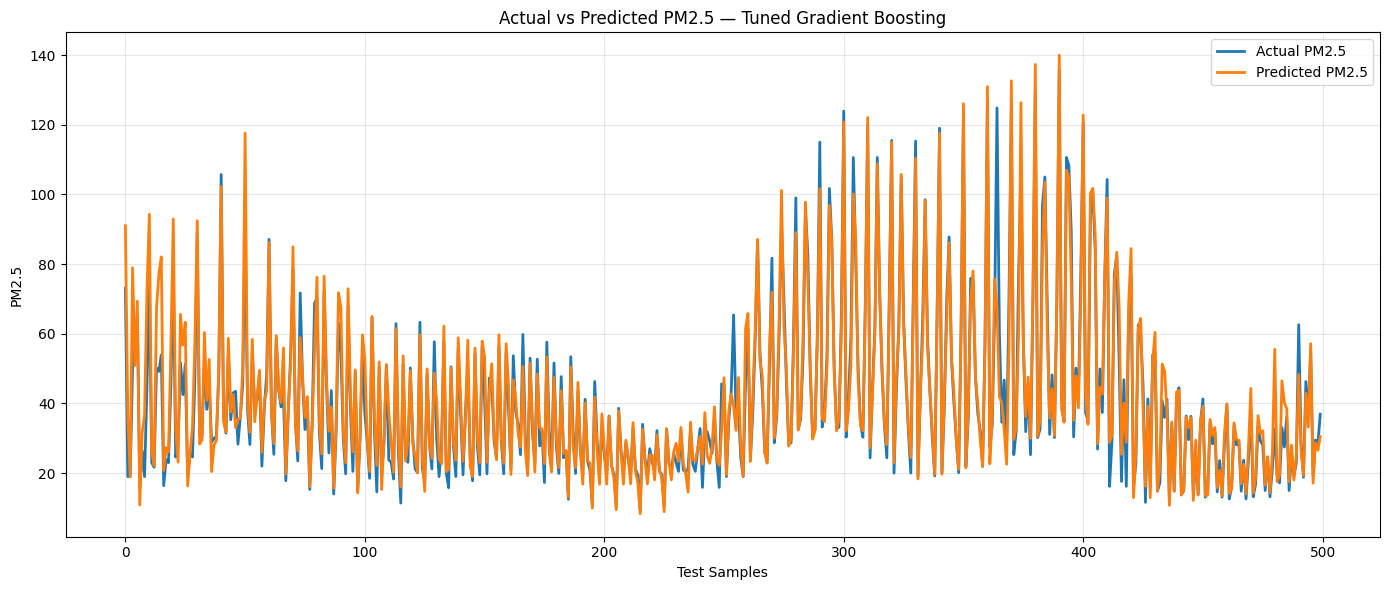

In [142]:
# ============================================
# STEP 12.13 — ACTUAL vs PREDICTED
# VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("ACTUAL vs PREDICTED PM2.5")
print("=" * 70)

# Limit points for cleaner visualization
n_points = min(500, len(y_test))

actual = np.asarray(y_test)[:n_points]
predicted = np.asarray(final_test_pred)[:n_points]

plt.figure(figsize=(14, 6))

plt.plot(
    actual,
    label="Actual PM2.5",
    linewidth=2
)

plt.plot(
    predicted,
    label="Predicted PM2.5",
    linewidth=2
)

plt.title(
    "Actual vs Predicted PM2.5 — Tuned Gradient Boosting"
)

plt.xlabel("Test Samples")
plt.ylabel("PM2.5")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12.14 — PREDICTION ERROR / RESIDUAL ANALYSIS

RESIDUAL ERROR ANALYSIS
Mean Residual : -0.3513
Std Residual  : 6.5845
Max Error     : 57.1865


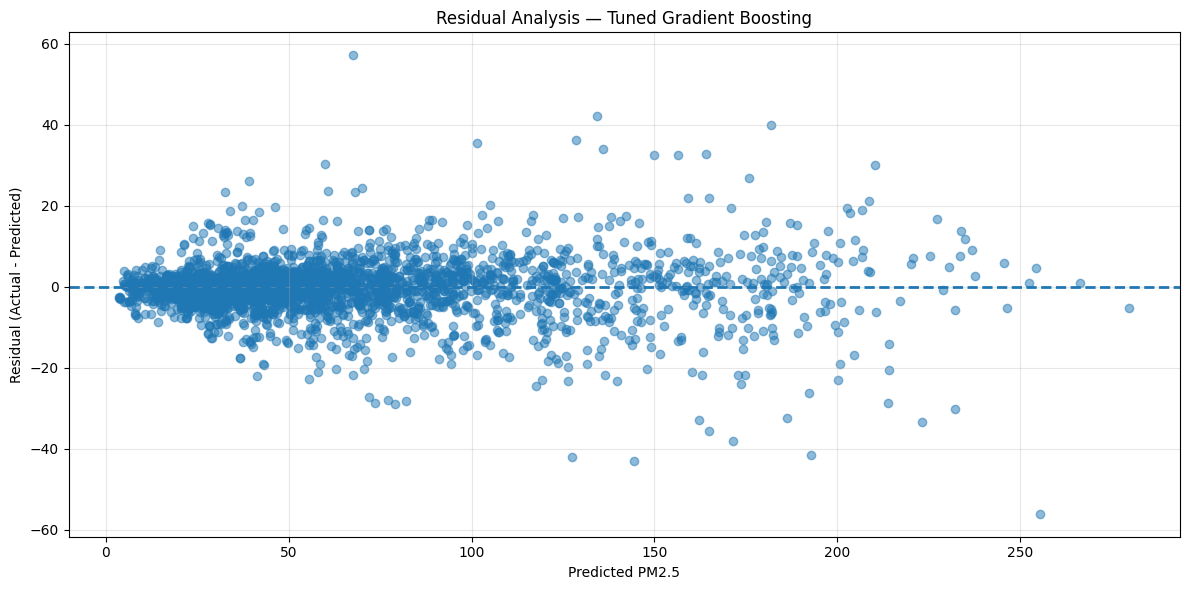

In [143]:
# ============================================
# STEP 12.14 — RESIDUAL / ERROR ANALYSIS
# ============================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("RESIDUAL ERROR ANALYSIS")
print("=" * 70)

residuals = np.asarray(y_test) - np.asarray(final_test_pred)

print(f"Mean Residual : {np.mean(residuals):.4f}")
print(f"Std Residual  : {np.std(residuals):.4f}")
print(f"Max Error     : {np.max(np.abs(residuals)):.4f}")

# Residual plot
plt.figure(figsize=(12, 6))

plt.scatter(
    final_test_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.title("Residual Analysis — Tuned Gradient Boosting")
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual (Actual - Predicted)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12.15 — FEATURE IMPORTANCE ANALYSIS

FEATURE IMPORTANCE ANALYSIS
Top 20 Important Features:


,Feature,Importance
0,num__pm2_5,0.886935
1,num__pm10,0.068091
2,num__pm2_5_change_1h,0.012846
3,num__hour_sin,0.009232
4,num__hour_cos,0.007669
5,num__pm2_5_rolling_mean_24h,0.003264
6,num__pm2_5_change_3h,0.002729
7,num__hour,0.001477
8,num__ozone_lag_3h,0.000733
9,num__pm2_5_change_6h,0.000622


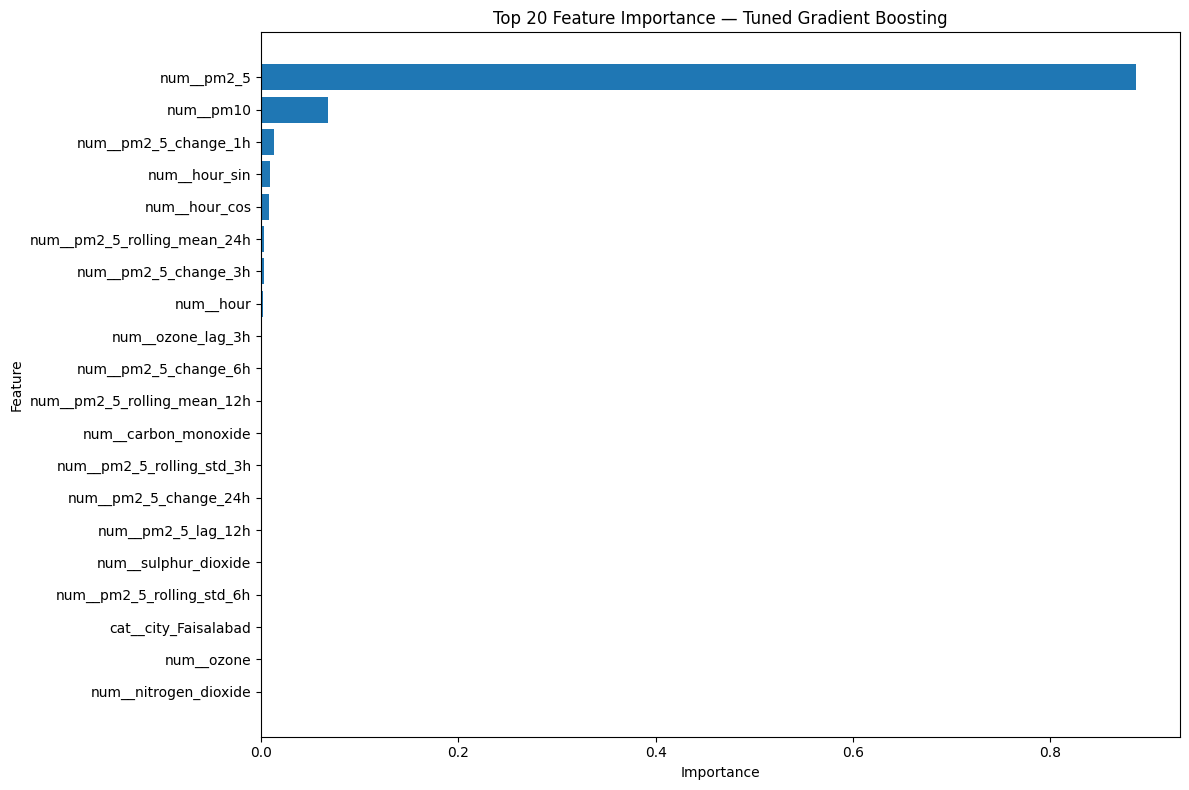

In [144]:
# ============================================
# STEP 12.15 — FEATURE IMPORTANCE ANALYSIS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Get processed feature names
processed_feature_names = preprocessor.get_feature_names_out()

# Get feature importance
feature_importance = final_gb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": feature_importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 Important Features:")
display(
    feature_importance_df.head(20).style.format({
        "Importance": "{:.6f}"
    })
)

# Plot top 20
top_features = feature_importance_df.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 20 Feature Importance — Tuned Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 12.16 — SAVE FINAL RESULTS

In [145]:
# ============================================
# STEP 12.16 — SAVE FINAL RESULTS
# ============================================

import os

models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

# Save model comparison
comparison_path = os.path.join(
    models_dir,
    "final_model_comparison.csv"
)

final_model_comparison.to_csv(
    comparison_path,
    index=False
)

# Save feature importance
importance_path = os.path.join(
    models_dir,
    "feature_importance.csv"
)

feature_importance_df.to_csv(
    importance_path,
    index=False
)

print("=" * 70)
print("FINAL RESULTS SAVED")
print("=" * 70)

print(f"Model comparison : {comparison_path}")
print(f"Feature importance: {importance_path}")

print("=" * 70)

FINAL RESULTS SAVED
Model comparison : models/final_model_comparison.csv
Feature importance: models/feature_importance.csv


In [146]:
# ============================================
# ZIP MODELS FOLDER
# ============================================

import shutil
import os

models_path = "/kaggle/working/models"
zip_base = "/kaggle/working/models"

# Create ZIP
zip_path = shutil.make_archive(
    zip_base,
    "zip",
    models_path
)

print("=" * 70)
print("MODELS FOLDER ZIPPED SUCCESSFULLY")
print("=" * 70)

print("ZIP file:")
print(zip_path)

print("\nZIP size:")
print(f"{os.path.getsize(zip_path) / (1024 * 1024):.2f} MB")

MODELS FOLDER ZIPPED SUCCESSFULLY
ZIP file:
/kaggle/working/models.zip

ZIP size:
0.21 MB
